In [3]:
import requests
import json
import math

import sys
import os
sys.path.append(os.path.abspath('..'))
from shared import generate
import time
import re

from scipy.stats import ttest_1samp
import pandas as pd
import numpy as np
from scipy.stats import ttest_rel
from scipy.stats import mannwhitneyu
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import seaborn as sns
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests


from datetime import datetime
from zoneinfo import ZoneInfo

from concurrent.futures import ThreadPoolExecutor, as_completed
import asyncio
from pathlib import Path
from itertools import product



## Metadata and Cleaning

### Filenames, Directories, and Variables

In [4]:


comparisons = [
    ("autistic", "no-context"),
    ("neurodivergent", "no-context"),
    ("neurodiversity-informed", "no-context"),
    ("autistic", "neurodivergent"),
]




### Cleaning Functions

In [5]:
def extract_rating(output):
    if pd.isna(output):
        return None

    text = re.sub(r"<think>.*?</think>", "", str(output), flags=re.DOTALL).strip()
    match = re.findall(r"\b[1-5]\b", text)

    return int(match[-1]) if match else None

def add_clean(df):
    df = df.copy()
    df["clean"] = df["output"].apply(extract_rating)
    return df

def drop_incomplete(df):
    df = df.copy()

    # step 1: get row_ids where clean is NaN
    bad_ids = df.loc[df["clean"].isna(), "row_id"].unique()
    bad_rows = df[df["clean"].isna()]

    #print(bad_rows)

    # step 2: drop all rows with those row_ids
    return df[~df["row_id"].isin(bad_ids)].reset_index(drop=True)

### Means, Differences, SF Functions

In [6]:
def calculate_differences(df,source_map,baseline_condition,value_col):
    aut_file = source_map["aut"]
    non_aut_file = source_map["non"]
    aut = df[df["source_file"] == aut_file].copy()
    non_aut = df[df["source_file"] == non_aut_file].copy()

    baseline = non_aut[non_aut["condition"] == baseline_condition][
        ["row_id", "model", value_col]
    ].copy()

    baseline = baseline.rename(columns={value_col: "baseline_clean"})

    merged = aut.merge(baseline, on=["row_id", "model"], how="inner")

    merged["diff"] = merged[value_col] - merged["baseline_clean"]

    return merged

In [7]:
def agg_means(df, attribute_list, value):
    agg = (
        df
        .groupby(attribute_list)[value]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    # standard error
    import numpy as np
    agg["se"] = agg["std"] / np.sqrt(agg["count"])

    return agg

In [8]:
def compute_baseline_significance(df, source_map, value_col="clean"):
    """
    Tests whether each condition differs from baseline.

    Baseline = blunt_non_aut + no-context
    """

    aut_file = source_map["aut"]
    non_aut_file = source_map["non"]

    results = []

    for model in df["model"].unique():
        df_model = df[df["model"] == model]

        baseline = df_model[
            (df_model["source_file"] == non_aut_file) &
            (df_model["condition"] == "no-context")
        ][["row_id", value_col]]

        for cond in ["no-context", "autistic", "neurodivergent", "neurodiversity-informed"]:

            cond_df = df_model[
                (df_model["source_file"] == aut_file) &
                (df_model["condition"] == cond)
            ][["row_id", value_col]]

            merged = baseline.merge(cond_df, on="row_id", suffixes=("_base", "_cond"))

            if len(merged) < 10 or (merged[f"{value_col}_base"] - merged[f"{value_col}_cond"]).nunique() <= 1:
                p = 1.0
            else:
                try:
                    stat, p = wilcoxon(
                        merged[f"{value_col}_base"],
                        merged[f"{value_col}_cond"]
                    )
                except:
                    p = 1.0

            results.append({
                "model": model,
                "condition": cond,
                "p_value": p
            })

    sig_df = pd.DataFrame(results)

    # multiple testing correction
    sig_df["p_adj"] = multipletests(sig_df["p_value"], method="fdr_bh")[1]
    sig_df["significant"] = sig_df["p_adj"] < 0.05

    return sig_df

In [7]:
def plot_condition_means(agg, orig_models,task):
    import matplotlib.pyplot as plt
    import numpy as np

    condition_order = [
        "no-context",
        "autistic",
        "neurodivergent",
        "neurodiversity-informed"
    ]

    conditions = [c for c in condition_order if c in agg["condition"].unique()]

    # sort only among models present in agg, then keep only those requested
    sorted_models = (
        agg.groupby("model")["mean"]
        .mean()
        .sort_values()
        .index.tolist()
    )

    models = [model for model in sorted_models if model in orig_models]

    x_positions = np.arange(len(models))
    offsets = np.linspace(-0.25, 0.25, len(conditions))

    color_map = {
    "no-context": "black",
    "autistic": "blue",
    "neurodivergent": "green",
    "neurodiversity-informed": "red"
    }

    marker_map = {
        "no-context": "x",
        "autistic": "o",
        "neurodivergent": "^",
        "neurodiversity-informed": "s"
    }

    label_map = { "no-context": "No context", "autistic": "Autistic", "neurodivergent": "Neurodivergent", "neurodiversity-informed": "ND-informed" }

    plt.figure(figsize=(11, 6))

    for i, cond in enumerate(conditions):
        subset = agg[agg["condition"] == cond].copy()
        subset = subset.set_index("model").reindex(models).reset_index()

        plt.errorbar(
            x_positions + offsets[i],
            subset["mean"],
            yerr=subset["se"],
            fmt=marker_map[cond],
            color=color_map[cond],
            ecolor=color_map[cond],
            capsize=3,
            markersize=6,
            linewidth=1,
            label=label_map.get(cond, cond)
        )

    plt.grid(axis='y', linestyle='--', alpha=0.3)

    for x in x_positions:
        plt.axvline(x, color='gray', alpha=0.08)

    plt.xticks(x_positions, models, rotation=45, ha="right", fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel("Model", fontsize = 10)
    plt.ylabel("Mean Difference (autistic-nonautistic)", fontsize = 10)
    plt.title(f"Mean Difference in {task} by Model and Condition")
    plt.legend(title="Condition", frameon=False, loc = "center left", bbox_to_anchor = (1.02,0.5))

    plt.tight_layout()
    plt.show()

## Initial Analyis for Visualising Mean Differences

#### Decision Making Tasks Metadata

In [10]:
def task_metadata(metric, dataset, source_tag):
    task = f"{metric}-ratings"
    jobs_file = f"{dataset}-{task}.csv"

    source_map = {
        "aut": f"{source_tag}_aut.json",
        "non": f"{source_tag}_non_aut.json",
}
    
    return task, jobs_file, dataset, source_map

In [9]:
# task = "hireability-ratings"
# dataset = "bluntness"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "blunt_aut.json",
#     "non": "blunt_non_aut.json",
# }

In [10]:
# task = "hireability-ratings"
# dataset = "figurative"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "figurative_aut.json",
#     "non": "figurative_non_aut.json",
# }

In [11]:
task = "hireability-ratings"
dataset = "indirect"
jobs_file = f"{dataset}-{task}.csv"

source_map = {
    "aut": "indirect_aut.json",
    "non": "indirect_non_aut.json",
}

In [12]:
# task = "dating-ratings"
# dataset = "bluntness"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "blunt_aut.json",
#     "non": "blunt_non_aut.json",
# }

In [13]:
# task = "dating-ratings"
# dataset = "figurative"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "figurative_aut.json",
#     "non": "figurative_non_aut.json",
# }

In [14]:
# task = "dating-ratings"
# dataset = "indirect"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "indirect_aut.json",
#     "non": "indirect_non_aut.json",
# }

In [15]:
# task = "admission-ratings"
# dataset = "bluntness"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "blunt_aut.json",
#     "non": "blunt_non_aut.json",
# }

In [16]:
# task = "admission-ratings"
# dataset = "figurative"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "figurative_aut.json",
#     "non": "figurative_non_aut.json",
# }

In [17]:
# task = "admission-ratings"
# dataset = "indirect"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "indirect_aut.json",
#     "non": "indirect_non_aut.json",
# }

In [18]:
# task = "triage-ratings"
# dataset = "bluntness"
# jobs_file = f"backup/{dataset}-{task}-backup.csv"

# source_map = {
#     "aut": "blunt_aut.json",
#     "non": "blunt_non_aut.json",
# }

In [19]:
# task = "clinician-ratings"
# dataset = "bluntness"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "blunt_aut.json",
#     "non": "blunt_non_aut.json",
# }

In [20]:
# task = "plausible-ratings"
# dataset = "bluntness"
# jobs_file = f"backup/{dataset}-{task}-backup.csv"

# source_map = {
#     "aut": "blunt_aut.json",
#     "non": "blunt_non_aut.json",
# }

#### Traits Tasks Metadata

In [21]:
# task = "clarity-ratings"
# dataset = "bluntness"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "blunt_aut.json",
#     "non": "blunt_non_aut.json",
# }

In [22]:
# task = "politeness-ratings"
# dataset = "bluntness"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "blunt_aut.json",
#     "non": "blunt_non_aut.json",
# }

In [23]:
# task = "honesty-ratings"
# dataset = "bluntness"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "blunt_aut.json",
#     "non": "blunt_non_aut.json",
# }

In [24]:
# task = "language-ratings"
# dataset = "bluntness"
# jobs_file = f"{dataset}-{task}.csv"

# source_map = {
#     "aut": "blunt_aut.json",
#     "non": "blunt_non_aut.json",
# }

### Calculating and Plotting Differences

In [25]:
models = {
    'llama3.2-1b': 'us.meta.llama3-2-1b-instruct-v1:0',
    'gpt4o-mini': '4o-mini',
    'gemini2.5-flash': 'gemini-2.5-flash',
    'sonnet4.5': 'us.anthropic.claude-sonnet-4-5-20250929-v1:0',
    'haiku4.5': 'us.anthropic.claude-haiku-4-5-20251001-v1:0',
    'gpt4o': 'gpt-4o',
    'llama3.3-70b': 'azure-llama3.3-70b',
    'gpt5.2': 'gpt-5.2',
    'deepseek-r1': 'azure-deepseek-r1',
}

In [26]:
df = pd.read_csv(jobs_file)
print(len(df))
df = df[df["model"] != "sonnet4.5"]
df = df[df["model"] != "haiku4.5"]
df = df[df["model"] != "llama3.2-1b"]
print(len(df))
clean_df = add_clean(df)    
print(len(df))
analysis_df = drop_incomplete(clean_df)
print(len(analysis_df))



7200
4800
4800
4704


In [27]:
def plot_condition_means(agg, orig_models, task, sig_df=None):
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd

    condition_order = [
        "no-context",
        "autistic",
        "neurodivergent",
        "neurodiversity-informed"
    ]

    conditions = [c for c in condition_order if c in agg["condition"].unique()]

    sorted_models = (
        agg.groupby("model")["mean"]
        .mean()
        .sort_values()
        .index.tolist()
    )

    models = [model for model in sorted_models if model in orig_models]

    x_positions = np.arange(len(models))
    offsets = np.linspace(-0.25, 0.25, len(conditions))

    color_map = {
        "no-context": "black",
        "autistic": "blue",
        "neurodivergent": "green",
        "neurodiversity-informed": "red"
    }

    marker_map = {
        "no-context": "x",
        "autistic": "o",
        "neurodivergent": "^",
        "neurodiversity-informed": "s"
    }

    label_map = {
        "no-context": "No context",
        "autistic": "Autistic",
        "neurodivergent": "Neurodivergent",
        "neurodiversity-informed": "ND-informed"
    }

    plt.figure(figsize=(11, 6))

    for i, cond in enumerate(conditions):
        subset = agg[agg["condition"] == cond].copy()
        subset = subset.set_index("model").reindex(models).reset_index()

        plt.errorbar(
            x_positions + offsets[i],
            subset["mean"],
            yerr=subset["se"],
            fmt=marker_map[cond],
            color=color_map[cond],
            ecolor=color_map[cond],
            capsize=3,
            markersize=6,
            linewidth=1,
            label=label_map.get(cond, cond)
        )

        # add significance stars relative to fixed baseline
        if sig_df is not None:
            sig_subset = sig_df[sig_df["condition"] == cond].copy()
            sig_subset = sig_subset.set_index("model").reindex(models).reset_index()

            for j, row in sig_subset.iterrows():
                if pd.notna(row["significant"]) and bool(row["significant"]):
                    y = subset.loc[j, "mean"]
                    err = subset.loc[j, "se"] if pd.notna(subset.loc[j, "se"]) else 0

                    plt.text(
                        x_positions[j] + offsets[i],
                        y + err + 0.04,
                        "*",
                        color=color_map[cond],
                        ha="center",
                        va="bottom",
                        fontsize=14,
                        fontweight="bold"
                    )

    plt.grid(axis='y', linestyle='--', alpha=0.3)

    for x in x_positions:
        plt.axvline(x, color='gray', alpha=0.08)

    plt.xticks(x_positions, models, rotation=45, ha="right", fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlabel("Model", fontsize=10)
    plt.ylabel("Mean Difference (baseline - condition)", fontsize=10)
    plt.title(f"Mean Difference in {task} by Model and Condition")

    plt.legend(
        title="Condition",
        frameon=False,
        loc="center left",
        bbox_to_anchor=(1.02, 0.5)
    )

    plt.tight_layout()
    plt.show()

In [28]:
def plot_differences(source_map, task, baseline = "no-context", diff_value = "clean", agg_value = "diff"):
    merged = calculate_differences(analysis_df, source_map, baseline, diff_value)
    #print(len(merged[merged['model_id']=='us.anthropic.claude-sonnet-4-5-20250929-v1:0']))
    print(len(merged))
    agg = agg_means(merged, ["model","condition"], agg_value)
    print("Min row:")
    print(agg.loc[agg["mean"].idxmin()])

    print("\nMax row:")
    print(agg.loc[agg["mean"].idxmax()])

    #print(agg)
    #plot_condition_means(agg, models, task)
    sig_df = compute_baseline_significance(analysis_df,source_map)
    plot_condition_means(agg, models, task=task, sig_df=sig_df)
    
    

2352
Min row:
model        gemini2.5-flash
condition         no-context
mean               -2.112245
std                  0.90682
count                     98
se                  0.091603
Name: 7, dtype: object

Max row:
model                   llama3.3-70b
condition    neurodiversity-informed
mean                        0.244898
std                         0.610243
count                             98
se                          0.061644
Name: 22, dtype: object


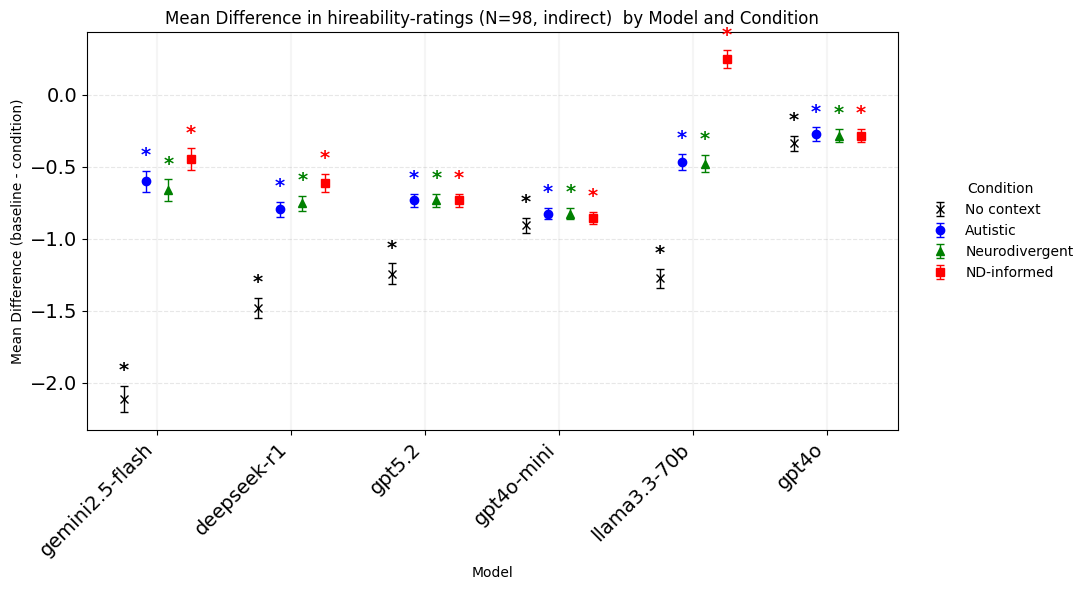

In [29]:
plot_differences(source_map = source_map, task = task + " (N=98, " + dataset + ") ")

## Findings (Direction and Magnitude of Bias)

In [207]:
metrics = ['hireability', 'dating','admission']
datasets = ['bluntness', 'figurative', 'indirect']
source_tags = ['blunt', 'figurative', 'indirect']


In [31]:
def calculate_overall_diff_mag(metrics,datasets,source_tags):
    for metric in metrics:
        for i in range(len(datasets)):
            dataset = datasets[i]
            source_tag = source_tags[i]
            task, jobs_file, dataset, source_map = task_metadata(metric,dataset,source_tag)
            df = pd.read_csv(jobs_file)
            df = df[df["model"] != "llama3.2-1b"]
            df = df[df["model"] != "sonnet4.5"]
            df = df[df["model"] != "haiku4.5"]
            # if metric == metrics[0] or metric ==metrics[2]:
            #     df = df[df["model"] != "sonnet4.5"]
            #     df = df[df["model"] != "haiku4.5"]
            clean_df = add_clean(df)
            analysis_df = drop_incomplete(clean_df)
            analysis_df = analysis_df[analysis_df['condition'] == 'no-context']
            # print(len(analysis_df))
            merged = calculate_differences(analysis_df, source_map, "no-context", "clean")
            mean_delta = merged["diff"].mean()
            mean_abs_delta = merged["diff"].abs().mean()
            pct_negative = (merged["diff"] < 0).mean()
            median_delta = merged["diff"].median()
            p10 = merged["diff"].quantile(0.10)
            p90 = merged["diff"].quantile(0.90)
            N = len(merged)
            print(len(merged['model'].unique()))
            print(jobs_file,mean_delta, mean_abs_delta, pct_negative,N, p10, p90, median_delta, "\n\n")



calculate_overall_diff_mag(metrics,datasets,source_tags)

6
bluntness-hireability-ratings.csv -0.7857142857142857 0.7959183673469388 0.5493197278911565 588 -2.0 0.0 -1.0 


6
figurative-hireability-ratings.csv -1.0850694444444444 1.2170138888888888 0.7083333333333334 576 -2.0 0.0 -1.0 


6
indirect-hireability-ratings.csv -1.2261904761904763 1.2261904761904763 0.7874149659863946 588 -2.0 0.0 -1.0 


6
bluntness-dating-ratings.csv -1.0707070707070707 1.0707070707070707 0.7525252525252525 594 -2.0 0.0 -1.0 


6
figurative-dating-ratings.csv -0.601010101010101 0.8838383838383839 0.5218855218855218 594 -2.0 1.0 -1.0 


6
indirect-dating-ratings.csv -0.5016666666666667 0.505 0.41833333333333333 600 -1.0 0.0 0.0 


6
bluntness-admission-ratings.csv -0.7738095238095238 0.7874149659863946 0.5663265306122449 588 -2.0 0.0 -1.0 


6
figurative-admission-ratings.csv -0.5733333333333334 0.8666666666666667 0.51 600 -2.0 1.0 -1.0 


6
indirect-admission-ratings.csv -0.8282828282828283 0.8383838383838383 0.6161616161616161 594 -2.0 0.0 -1.0 




In [208]:
def p_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""
    
def calculate_affect_prompt(metrics,datasets,source_tags):
    rows = []
    for metric in metrics:
        for i in range(len(datasets)):
            dataset = datasets[i]
            source_tag = source_tags[i]
            task, jobs_file, dataset, source_map = task_metadata(metric,dataset,source_tag)
            df = pd.read_csv(jobs_file)
            df = df[df["model"] != "llama3.2-1b"]
            df = df[df["model"] != "sonnet4.5"]
            df = df[df["model"] != "haiku4.5"]
            # if metric == metrics[0] or metric ==metrics[2]:
            #     df = df[df["model"] != "sonnet4.5"]
            #     df = df[df["model"] != "haiku4.5"]
            clean_df = add_clean(df)
            analysis_df = drop_incomplete(clean_df)
            # analysis_df = analysis_df[analysis_df['condition'] == 'no-context']
            # print(len(analysis_df))
            merged = calculate_differences(analysis_df, source_map, "no-context", "clean")
            conditions = [c for c in merged["condition"].dropna().unique() if c != "no-context"]
            baseline_df = merged[merged["condition"] == "no-context"]
            for cond in conditions:
                cond_df = merged[merged["condition"] == cond]

                paired = baseline_df.merge(
                    cond_df,
                    on=["row_id", "model"],
                    suffixes=("_base", "_cond")
                )

                paired["shift"] = paired["diff_cond"] - paired["diff_base"]
                paired_row = paired.groupby("row_id")["shift"].mean()

                mean_shift = paired_row.mean()
                pct_improved = (paired_row > 0).mean()
                pct_worsened = (paired_row < 0).mean()
                N = len(paired_row)

                t_stat, p_value = ttest_1samp(paired_row, 0)
                stars = p_to_stars(p_value)
                rows.append({
                    "task": task,                      # make sure this exists in your loop
                    "dialogue_type": dataset,    # same here
                    "condition": cond,
                    "mean_shift": mean_shift,
                    "pct_improved": pct_improved,
                    "pct_worsened": pct_worsened,
                    "N": N,
                    "t_stat": t_stat,
                    "p_value": p_value,
                    "significance": stars
                })
        
    return pd.DataFrame(rows)


prompt_effect_df = calculate_affect_prompt(metrics,datasets,source_tags)

reject, pvals_corrected, _, _ = multipletests(
    prompt_effect_df["p_value"],
    method="fdr_bh"
)

prompt_effect_df["p_corrected"] = pvals_corrected




In [263]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_prompt_effects(df, palette):
    df = df.copy()


    # clean labels
    df["task"] = df["task"].str.replace("-ratings", "", regex=False).str.capitalize()
    df["dialogue_type"] = df["dialogue_type"].str.capitalize()
    df["condition"] = df["condition"].str.replace("-", " ").str.capitalize()

    df["dialogue_type"] = df["dialogue_type"].replace({
        "Bluntness": "Blunt",
        "Figurative": "Figurative",
        "Indirect": "Indirect"
    })

    condition_order = ["Autistic", "Neurodivergent", "Neurodiversity informed"]

#     palette = {
#     "Autistic": "#C084D4",                  # soft lavender / purple
#     "Neurodivergent": "#F2A6B3",            # warm pink
#     "Neurodiversity informed": "#9FD3C7"    # soft mint-teal
# }
    hatches = {
        "Autistic": "//",
        "Neurodivergent": "",
        "Neurodiversity informed": "oo"
    }

    g = sns.catplot(
        data=df,
        kind="bar",
        x="task",
        y="mean_shift",
        hue="condition",
        hue_order=condition_order,
        col="dialogue_type",
        palette=palette,
        ci=None,
        height=4,
        aspect=1
    )

    # remove "dialogue_type =" from titles
    g.set_titles("{col_name}")

    # apply hatches + styling
    for ax in g.axes.flat:
        for bars, cond in zip(ax.containers, condition_order):
            for bar in bars:
                bar.set_hatch(hatches[cond])
                bar.set_edgecolor("black")

        ax.set_xlabel("")  # remove repeated x labels
        ax.set_ylabel("Mean Shift in Rating", fontsize=14)
        ax.tick_params(axis='both', labelsize=14)

    # single centered x-axis label
    #g.fig.supxlabel("Decision Making Task", fontsize=14, y=0.02)

    # rebuild legend with hatches
    import matplotlib.patches as mpatches
    legend_patches = [
        mpatches.Patch(
            facecolor=palette[c],
            hatch=hatches[c],
            edgecolor="black",
            label=c
        )
        for c in condition_order
    ]

    g._legend.remove()

    #g.fig.text(0.3, -0.08, "Prompt Conditions:", fontsize=14)
    g.fig.legend(
    handles=legend_patches,
    loc="lower center",
    bbox_to_anchor=(0.43, -0.1),
    ncol=3,
    frameon=False,
    fontsize=14,
    title_fontsize=14
)

    for ax in g.axes.flat:
        ax.set_title(ax.get_title(), fontsize=14)
    #plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()

/var/folders/30/7js64q2522sb_sszvtx_30_00000gn/T/ipykernel_2409/448482233.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(


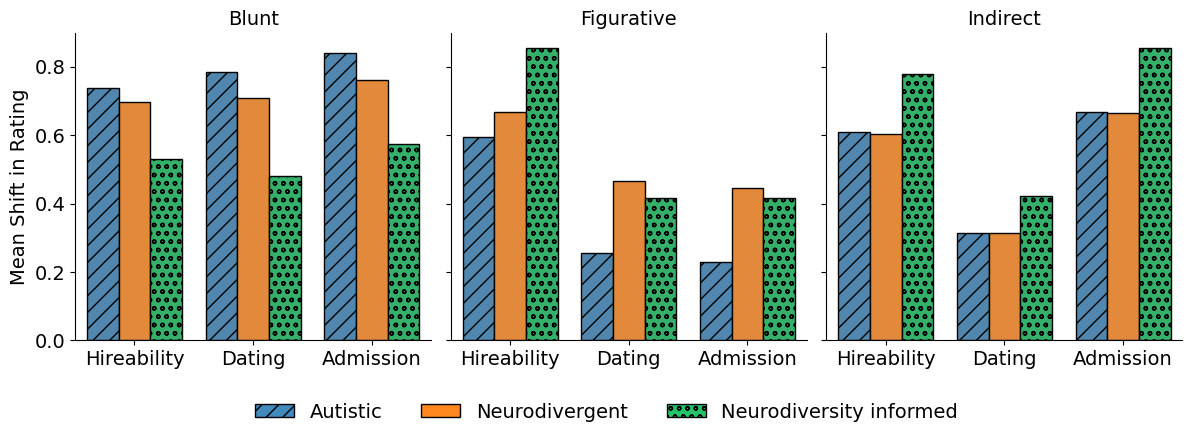

In [264]:


plot_prompt_effects(prompt_effect_df, palette = {
    "Autistic": "#418ABE",                  # your blue
    "Neurodivergent": "#FF871F",            # your orange
    "Neurodiversity informed": "#21C468"    # soft lavender
})

In [266]:
def check_gap(metrics, datasets, source_tags):
    rows = []
    for metric in metrics:
        for i in range(len(datasets)):
            dataset = datasets[i]
            source_tag = source_tags[i]
            task, jobs_file, dataset, source_map = task_metadata(metric, dataset, source_tag)

            df = pd.read_csv(jobs_file)
            df = df[df["model"] != "llama3.2-1b"]
            df = df[df["model"] != "sonnet4.5"]
            df = df[df["model"] != "haiku4.5"]

            clean_df = add_clean(df)
            analysis_df = drop_incomplete(clean_df)

            merged = calculate_differences(analysis_df, source_map, "no-context", "clean")
            conditions = [c for c in merged["condition"].dropna().unique() if c != "no-context"]

            for cond in conditions:
                cond_df = merged[merged["condition"] == cond].copy()

                # row_id is the unit of analysis
                cond_row = cond_df.groupby("row_id")["diff"].mean()

                mean_gap = cond_row.mean()
                pct_non_aut_higher = (cond_row < 0).mean()
                pct_aut_higher = (cond_row > 0).mean()
                pct_equal = (cond_row == 0).mean()
                N = len(cond_row)

                t_stat, p_value = ttest_1samp(cond_row, 0)
                stars = p_to_stars(p_value)

                rows.append({
                    "task": task,
                    "dialogue_type": dataset,
                    "condition": cond,
                    "mean_gap": mean_gap,
                    "pct_non_aut_higher": pct_non_aut_higher,
                    "pct_aut_higher": pct_aut_higher,
                    "pct_equal": pct_equal,
                    "N": N,
                    "t_stat": t_stat,
                    "p_value": p_value,
                    "significance": stars
                })

    return pd.DataFrame(rows)

In [267]:
gap_df = check_gap(metrics,datasets,source_tags)


/var/folders/30/7js64q2522sb_sszvtx_30_00000gn/T/ipykernel_2409/1634814071.py:38: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(


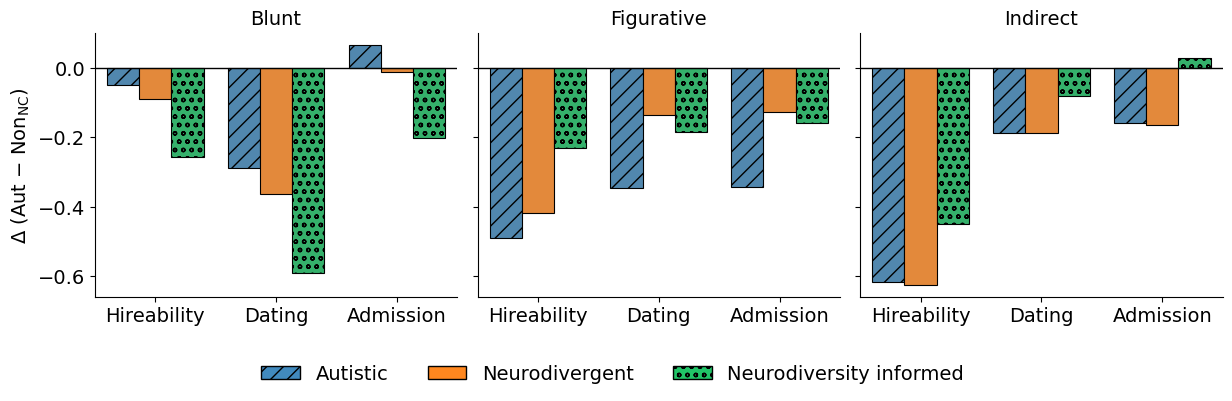

In [269]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df = gap_df.copy()

# clean labels
df["task"] = df["task"].str.replace("-ratings", "", regex=False).str.capitalize()
df["dialogue_type"] = df["dialogue_type"].str.replace("-", " ", regex=False).str.capitalize()
df["condition"] = df["condition"].str.replace("-", " ", regex=False).str.capitalize()

df["dialogue_type"] = df["dialogue_type"].replace({
    "Bluntness": "Blunt",
    "Figurative": "Figurative",
    "Indirect": "Indirect"
})

task_order = ["Hireability", "Dating", "Admission", "Admissions"]
task_order = [t for t in task_order if t in df["task"].unique()]

dialogue_order = ["Blunt", "Figurative", "Indirect"]
dialogue_order = [d for d in dialogue_order if d in df["dialogue_type"].unique()]

condition_order = ["Autistic", "Neurodivergent", "Neurodiversity informed"]

palette = {
    "Autistic": "#418ABE",                  # your blue
    "Neurodivergent": "#FF871F",            # your orange
    "Neurodiversity informed": "#21C468"    # soft lavender
}

hatches = {
    "Autistic": "//",
    "Neurodivergent": "",
    "Neurodiversity informed": "oo"
}

g = sns.catplot(
    data=df,
    kind="bar",
    x="task",
    y="mean_gap",
    hue="condition",
    hue_order=condition_order,
    col="dialogue_type",
    col_order=dialogue_order,
    order=task_order,
    palette=palette,
    ci=None,
    height=4,
    aspect=1
)

g.set_titles("{col_name}")

for ax in g.axes.flat:
    ax.axhline(0, color="black", linewidth=1)

    for bars, cond in zip(ax.containers, condition_order):
        for bar in bars:
            bar.set_hatch(hatches[cond])
            bar.set_edgecolor("black")
            bar.set_linewidth(0.8)

    ax.set_xlabel("")
    ax.set_ylabel(r"$\Delta$ (Aut − Non$_{\mathrm{NC}}$)", fontsize=14)
    ax.tick_params(axis="both", labelsize=14)

# custom legend so hatches appear
legend_patches = [
    mpatches.Patch(
        facecolor=palette[c],
        hatch=hatches[c],
        edgecolor="black",
        label=c
    )
    for c in condition_order
]

if g._legend is not None:
    g._legend.remove()

    g.fig.legend(
    handles=legend_patches,
    loc="lower center",
    bbox_to_anchor=(0.43, -0.1),
    ncol=3,
    frameon=False,
    fontsize=14,
    title_fontsize=14
)

#g.fig.supxlabel("Task", fontsize=14, y=0.0)
# g.fig.suptitle("Residual Gap After Prompt Framing", fontsize=14)

for ax in g.axes.flat:
    ax.set_title(ax.get_title(), fontsize=14)


plt.subplots_adjust(top=0.82, bottom=0.16, right=0.86)
plt.show()

In [38]:
# def filter_uniform_by_dialogue_type(metrics, datasets, source_tags):
#     """
#     For each dialogue type:
#     1. Read each task file
#     2. Clean using add_clean + drop_incomplete
#     3. Track row_ids lost in any file for that dialogue type
#     4. Remove the union of all lost row_ids from every cleaned file
#     5. Return uniform cleaned dfs per dialogue type and task

#     Returns:
#         result[dialogue_type][task] = filtered dataframe
#     """
#     result = {}

#     for dataset, source_tag in zip(datasets, source_tags):
#         dialogue_type = source_tag

#         cleaned_task_dfs = {}
#         lost_row_ids_for_type = set()

#         # first pass: clean each file and track lost row_ids
#         for metric in metrics:
#             task, jobs_file, dataset_name, source_map = task_metadata(metric, dataset, source_tag)

#             df = pd.read_csv(jobs_file)

#             # optional: filter out unwanted models here if needed
#             df = df[
#                 ~df["model"].isin(["llama3.2-1b", "sonnet4.5", "haiku4.5"])
#             ].copy()

#             original_row_ids = set(df["row_id"].unique())

#             clean_df = add_clean(df)
#             filtered_df = drop_incomplete(clean_df)

#             kept_row_ids = set(filtered_df["row_id"].unique())
#             lost_ids_this_file = original_row_ids - kept_row_ids

#             lost_row_ids_for_type.update(lost_ids_this_file)

#             cleaned_task_dfs[task] = {
#                 "df": filtered_df,
#                 "source_map": source_map,
#                 "jobs_file": jobs_file,
#             }

#             print(
#                 f"{dialogue_type} | {task}: "
#                 f"started with {len(original_row_ids)} row_ids, "
#                 f"lost {len(lost_ids_this_file)}, "
#                 f"kept {len(kept_row_ids)} before dialogue-type alignment"
#             )

#         # second pass: remove all lost row_ids for this dialogue type from every task df
#         result[dialogue_type] = {}

#         print(f"{dialogue_type}: total union of lost row_ids across tasks = {len(lost_row_ids_for_type)}")

#         for task, item in cleaned_task_dfs.items():
#             df = item["df"].copy()

#             df = df[~df["row_id"].isin(lost_row_ids_for_type)].reset_index(drop=True)

#             result[dialogue_type][task] = df

#             print(
#                 f"{dialogue_type} | {task}: "
#                 f"{df['row_id'].nunique()} row_ids after uniform filtering"
#             )

#     return result

In [39]:

# uniform_data = filter_uniform_by_dialogue_type(metrics, datasets, source_tags)


In [40]:
import pandas as pd
import numpy as np

def summarize_model_consistency(metrics, datasets, source_tags):
    model_rows = []

    for metric in metrics:
        for i in range(len(datasets)):
            dataset = datasets[i]
            source_tag = source_tags[i]

            task, jobs_file, dataset_name, source_map = task_metadata(metric, dataset, source_tag)

            df = pd.read_csv(jobs_file)
            df = df[~df["model"].isin(["llama3.2-1b", "sonnet4.5", "haiku4.5"])].copy()

            clean_df = add_clean(df)
            analysis_df = drop_incomplete(clean_df)

            merged = calculate_differences(analysis_df, source_map, "no-context", "clean")

            # include no-context too
            conditions = [c for c in merged["condition"].dropna().unique()]

            for cond in conditions:
                cond_df = merged[merged["condition"] == cond].copy()

                per_model = (
                    cond_df.groupby("model")["diff"]
                    .agg(
                        mean_gap="mean",
                        median_gap="median",
                        std_gap="std",
                        n="size"
                    )
                    .reset_index()
                )

                for _, r in per_model.iterrows():
                    model_rows.append({
                        "task": task.replace("-ratings", "").capitalize(),
                        "dialogue_type": dataset_name.capitalize() if isinstance(dataset_name, str) else source_tag.capitalize(),
                        "source_tag": source_tag,
                        "condition": cond,
                        "model": r["model"],
                        "mean_gap": r["mean_gap"],
                        "median_gap": r["median_gap"],
                        "std_gap": r["std_gap"],
                        "n": r["n"],
                    })

    return pd.DataFrame(model_rows)

In [41]:
model_df = summarize_model_consistency(metrics, datasets, source_tags)

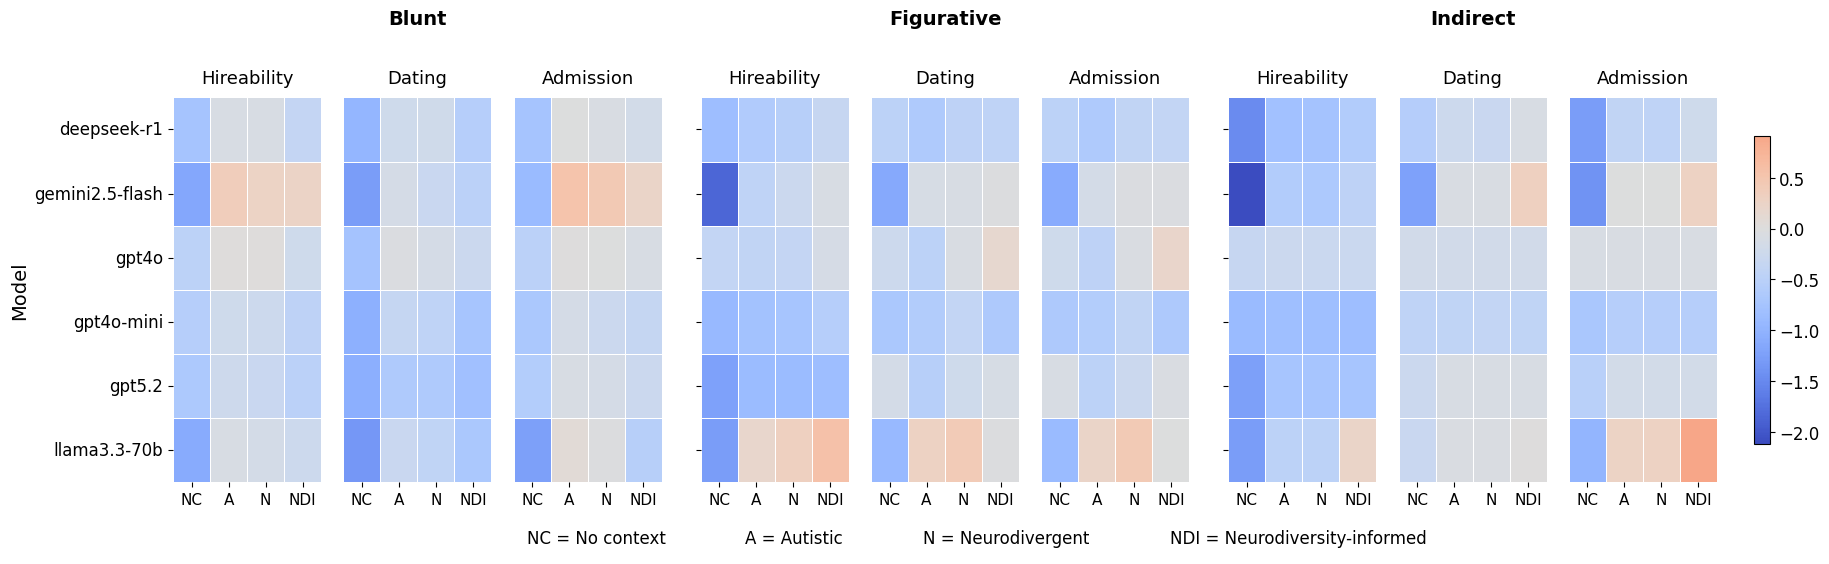

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import gridspec

df = model_df.copy()

# clean labels
df["task"] = df["task"].str.replace("-ratings", "", regex=False).str.capitalize()

df["condition"] = df["condition"].replace({
    "no-context": "NC",
    "autistic": "A",
    "neurodivergent": "N",
    "neurodiversity-informed": "NDI",
    "No-context": "NC",
    "Autistic": "A",
    "Neurodivergent": "N",
    "Neurodiversity informed": "NDI"
})

df["dialogue_type"] = df["dialogue_type"].replace({
    "Bluntness": "Blunt",
    "Figurative": "Figurative",
    "Indirect": "Indirect"
})

task_order = ["Hireability", "Dating", "Admission"]
task_order = [t for t in task_order if t in df["task"].unique()]

condition_order = ["NC", "A", "N", "NDI"]
condition_order = [c for c in condition_order if c in df["condition"].unique()]

dialogue_order = ["Blunt", "Figurative", "Indirect"]
dialogue_order = [d for d in dialogue_order if d in df["dialogue_type"].unique()]

model_order = sorted(df["model"].unique())

vmin = df["mean_gap"].min()
vmax = df["mean_gap"].max()

fig = plt.figure(figsize=(24, 5))
outer = gridspec.GridSpec(1, len(dialogue_order), wspace=0.08)

last_hm = None

for i, dialogue in enumerate(dialogue_order):
    sub = df[df["dialogue_type"] == dialogue].copy()

    # inner grid: one small heatmap per task, with spacing
    inner = gridspec.GridSpecFromSubplotSpec(
        1, len(task_order),
        subplot_spec=outer[i],
        wspace=0.15
    )

    task_axes = []

    for j, task in enumerate(task_order):
        ax = plt.Subplot(fig, inner[j])
        fig.add_subplot(ax)
        task_axes.append(ax)

        task_sub = sub[sub["task"] == task].copy()

        pivot = task_sub.pivot_table(
            index="model",
            columns="condition",
            values="mean_gap",
            aggfunc="mean"
        )

        pivot = pivot.reindex(index=model_order, columns=condition_order)

        hm = sns.heatmap(
            pivot,
            ax=ax,
            cmap="coolwarm",
            center=0,
            vmin=vmin,
            vmax=vmax,
            cbar=False,
            linewidths=0.5,
            linecolor="white"
        )
        last_hm = hm

        ax.set_title(task, fontsize=13, pad=10)
        ax.set_xlabel("")
        ax.set_xticklabels(condition_order, rotation=0, ha="center", fontsize=11)

                # only show y-axis for very first subplot (i==0 and j==0)
        if i == 0 and j == 0:
            ax.set_ylabel("Model", fontsize=14)
            ax.tick_params(axis="y", labelsize=12)
        elif j == 0:
            # keep ticks aligned but hide labels
            ax.set_ylabel("")
            ax.tick_params(axis="y", labelleft=False)
        else:
            ax.set_ylabel("")
            ax.set_yticklabels([])
            ax.tick_params(axis="y", left=False)

    # dialogue title centered over the middle task panel
    task_axes[len(task_axes)//2].text(
        0.5, 1.18, dialogue,
        transform=task_axes[len(task_axes)//2].transAxes,
        ha="center", va="bottom",
        fontsize=14, fontweight="bold"
    )

# single colorbar
cbar = fig.colorbar(last_hm.collections[0], ax=fig.axes, shrink=0.8, pad=0.02)
cbar.ax.tick_params(labelsize=12)


legend_elements = [
    mpatches.Patch(facecolor='none', edgecolor='none', label='NC = No context'),
    mpatches.Patch(facecolor='none', edgecolor='none', label='A = Autistic'),
    mpatches.Patch(facecolor='none', edgecolor='none', label='N = Neurodivergent'),
    mpatches.Patch(facecolor='none', edgecolor='none', label='NDI = Neurodiversity-informed')
]

fig.legend(
    handles=legend_elements,
    loc='lower center',
    bbox_to_anchor=(0.45, -0.05),
    ncol=4,
    frameon=False,
    fontsize=12
)


plt.show()

In [43]:
def model_extremes_table(model_df):
    df = model_df.copy()

    rows = []

    print(model_df.columns)

    grouped = df.groupby(["dialogue_type", "task", "condition"])

    for (dialogue, task, cond), group in grouped:
        if group.empty:
            continue

        min_row = group.loc[group["mean_gap"].idxmax()]  # closest to 0 (best)
        max_row = group.loc[group["mean_gap"].idxmin()]  # most negative (worst)

        rows.append({
            "dialogue_type": dialogue,
            "task": task,
            "condition": cond,
            "min_gap": min_row["mean_gap"],
            "min_model": min_row["model"],
            "max_gap": max_row["mean_gap"],
            "max_model": max_row["model"],
            "mean_gap": group["mean_gap"].mean(),
            "std_gap": group["mean_gap"].std(),
            "range": group["mean_gap"].max() - group["mean_gap"].min()
        })

    return pd.DataFrame(rows)

In [44]:
extreme_df = model_extremes_table(model_df)
#extreme_df

Index(['task', 'dialogue_type', 'source_tag', 'condition', 'model', 'mean_gap',
       'median_gap', 'std_gap', 'n'],
      dtype='object')


In [45]:
def model_extremes_table(model_df):
    df = model_df.copy()
    rows = []

    cond_map = {
        "no-context": "NC",
        "autistic": "A",
        "neurodivergent": "N",
        "neurodiversity-informed": "NDI"
    }

    grouped = df.groupby(["dialogue_type", "task"])

    for (dialogue, task), group in grouped:
        if group.empty:
            continue

        max_row = group.loc[group["mean_gap"].idxmax()]
        min_row = group.loc[group["mean_gap"].idxmin()]
        zero_row = group.loc[group["mean_gap"].abs().idxmin()]

        rows.append({
            "dialogue_type": dialogue,
            "task": task,

            # MAX
            "max_model": max_row["model"],
            "max_condition": cond_map.get(max_row["condition"], max_row["condition"]),
            "max_diff": max_row["mean_gap"],

            # MIN
            "min_model": min_row["model"],
            "min_condition": cond_map.get(min_row["condition"], min_row["condition"]),
            "min_diff": min_row["mean_gap"],

            # CLOSEST
            "closest_model": zero_row["model"],
            "closest_condition": cond_map.get(zero_row["condition"], zero_row["condition"]),
            "closest_to_0": zero_row["mean_gap"],
        })

    return pd.DataFrame(rows)

In [46]:
ex_model = model_extremes_table(model_df)
print(ex_model)

  dialogue_type         task        max_model max_condition  max_diff  \
0     Bluntness    Admission  gemini2.5-flash             A  0.540816   
1     Bluntness       Dating            gpt4o             A -0.040404   
2     Bluntness  Hireability  gemini2.5-flash             A  0.357143   
3    Figurative    Admission     llama3.3-70b             N  0.430000   
4    Figurative       Dating     llama3.3-70b             N  0.424242   
5    Figurative  Hireability     llama3.3-70b           NDI  0.572917   
6      Indirect    Admission     llama3.3-70b           NDI  0.909091   
7      Indirect       Dating  gemini2.5-flash           NDI  0.320000   
8      Indirect  Hireability     llama3.3-70b           NDI  0.244898   

         min_model min_condition  min_diff    closest_model closest_condition  \
0     llama3.3-70b            NC -1.244898      deepseek-r1                 A   
1     llama3.3-70b            NC -1.333333            gpt4o                 A   
2  gemini2.5-flash        

In [87]:

metrics = ['hireability', 'dating', 'admission']
datasets = ['bluntness']
source_tags = ['blunt']




def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

def self_nonself_balanced(metrics, datasets, source_tags, random_state=42):
    rows = []

    excluded_models = {"llama3.2-1b", "sonnet4.5", "haiku4.5"}

    for metric in metrics:
        for i in range(len(datasets)):
            dataset = datasets[i]
            source_tag = source_tags[i]

            task, jobs_file, dataset_name, source_map = task_metadata(metric, dataset, source_tag)

            df = pd.read_csv(jobs_file)
            df = df[~df["model"].isin(excluded_models)].copy()

            clean_df = add_clean(df)
            analysis_df = drop_incomplete(clean_df)

            merged = calculate_differences(analysis_df, source_map, "no-context", "clean").copy()
            merged["task"] = task

            for (task_name, cond, model), group in merged.groupby(["task", "condition", "model"]):
                g_self = group[group["label"] == "self"]["diff"].dropna()
                g_non = group[group["label"] == "nonself"]["diff"].dropna()

                n_self = len(g_self)
                n_non = len(g_non)

                if n_self == 0 or n_non == 0:
                    continue

                n = min(n_self, n_non)

                g_self_bal = g_self.sample(n=n, random_state=random_state) if n_self > n else g_self
                g_non_bal = g_non.sample(n=n, random_state=random_state) if n_non > n else g_non

                test = ttest_ind(g_self_bal, g_non_bal, equal_var=False)
                p_val = test.pvalue

                rows.append({
                    "task": task_name,
                    "condition": cond,
                    "model": model,
                    "n_per_group": n,
                    "mean_self": g_self_bal.mean(),
                    "mean_nonself": g_non_bal.mean(),
                    "mean_diff": g_self_bal.mean() - g_non_bal.mean(),
                    "p_value": p_val,
                })

    result = pd.DataFrame(rows)

    if result.empty:
        return result

    # FDR correction
    result["p_adj"] = multipletests(result["p_value"], method="fdr_bh")[1]
    result["sig"] = result["p_adj"].apply(p_to_stars)

    # ordering + labels
    task_order = ["hireability-ratings", "dating-ratings", "admission-ratings"]
    condition_order = ["no-context", "autistic", "neurodivergent", "neurodiversity-informed"]
    cond_map = {
        "no-context": "NC",
        "autistic": "A",
        "neurodivergent": "N",
        "neurodiversity-informed": "NDI"
    }

    result["task"] = pd.Categorical(result["task"], categories=task_order, ordered=True)
    result["condition"] = pd.Categorical(result["condition"], categories=condition_order, ordered=True)

    result = result.sort_values(["task", "condition", "model"]).copy()
    result["condition_short"] = result["condition"].map(cond_map)

    return result


In [88]:
result = self_nonself_balanced(metrics, datasets, source_tags)
summary = (
    result
    .groupby(["task", "condition"])
    .agg(
        mean_diff=("mean_diff", "mean"),
        n_models=("model", "count"),
        n_sig=("p_adj", lambda x: (x < 0.05).sum())
    )
    .reset_index()
)
summary["sig_models"] = summary["n_sig"].astype(str) + "/" + summary["n_models"].astype(str)
print(summary)

                   task                condition  mean_diff  n_models  n_sig  \
0   hireability-ratings               no-context  -0.787234         6      6   
1   hireability-ratings                 autistic  -0.407801         6      2   
2   hireability-ratings           neurodivergent  -0.482270         6      3   
3   hireability-ratings  neurodiversity-informed  -1.177305         6      6   
4        dating-ratings               no-context  -0.440972         6      5   
5        dating-ratings                 autistic  -0.284722         6      2   
6        dating-ratings           neurodivergent  -0.406250         6      4   
7        dating-ratings  neurodiversity-informed  -1.135417         6      6   
8     admission-ratings               no-context  -0.729167         6      6   
9     admission-ratings                 autistic  -0.361111         6      3   
10    admission-ratings           neurodivergent  -0.489583         6      5   
11    admission-ratings  neurodiversity-

/var/folders/30/7js64q2522sb_sszvtx_30_00000gn/T/ipykernel_2409/3289637325.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["task", "condition"])


In [117]:
task_name = "hireability-ratings"

best_model = (
    result[result["task"] == task_name]
    .sort_values("mean_diff")
    .iloc[0]["model"]
)

print(best_model)

llama3.3-70b


In [204]:
import numpy as np
import matplotlib.pyplot as plt

def plot_self_nonself_bars_and_lines(
    merged,
    model_name,
    task_name,
    smooth=False,
    smooth_kernel=None
):
    df = merged.copy()

    df = df[
        (df["model"] == model_name) &
        (df["task"] == task_name)
    ].copy()

    cond_order = ["no-context", "autistic", "neurodivergent", "neurodiversity-informed"]
    cond_titles = ["No-context", "Autistic", "Neurodivergent", "Neurodiversity-informed"]

    diff_vals = sorted(df["diff"].dropna().unique())
    x = np.arange(len(diff_vals))
    width = 0.38

    if smooth_kernel is None:
        smooth_kernel = np.array([1, 2, 3, 2, 1], dtype=float)
        smooth_kernel = smooth_kernel / smooth_kernel.sum()

    fig, axes = plt.subplots(1, 4, figsize=(15, 4), sharey=True)

    for i, (ax, cond, title) in enumerate(zip(axes, cond_order, cond_titles)):
        sub = df[df["condition"] == cond]

        self_counts = (
            sub[sub["label"] == "self"]["diff"]
            .value_counts(normalize=True)
            .reindex(diff_vals, fill_value=0)
            .values
        )

        nonself_counts = (
            sub[sub["label"] == "nonself"]["diff"]
            .value_counts(normalize=True)
            .reindex(diff_vals, fill_value=0)
            .values
        )

        self_line = self_counts.copy()
        nonself_line = nonself_counts.copy()

        if smooth and len(diff_vals) >= len(smooth_kernel):
            self_line = np.convolve(self_line, smooth_kernel, mode="same")
            nonself_line = np.convolve(nonself_line, smooth_kernel, mode="same")

        # bars
        ax.bar(
            x - width/2,
            self_counts,
            width=width,
            alpha=0.6,
            hatch="///",
            edgecolor="black",
            label="Self" if i == 0 else ""
        )
        ax.bar(
            x + width/2,
            nonself_counts,
            width=width,
            alpha=0.6,
            edgecolor="black",
            label="Nonself" if i == 0 else ""
        )

        # lines
        if smooth:
            ax.plot(x - width/2, self_line, marker="o", linewidth=2)
            ax.plot(x + width/2, nonself_line, marker="o", linewidth=2)
        else:
            ax.plot(x - width/2, self_counts, marker="o", linewidth=2)
            ax.plot(x + width/2, nonself_counts, marker="o", linewidth=2)

        ax.set_title(title, fontsize=14)
        ax.set_xticks(x)
        ax.set_xticklabels([int(v) for v in diff_vals], fontsize=14)
        ax.tick_params(axis='y', labelsize=14)

        ax.axhline(0, linewidth=1)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Proportion", fontsize=14)

    # ONE global x-axis label
    fig.supxlabel("Difference in Rating from Non-autistic No-context Baseline", fontsize=14, y=0.12)   # move up

    # legend below
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=2,
        frameon=False,
        bbox_to_anchor=(0.5, -0.05),
        fontsize=14
    )

    plt.suptitle(f"{model_name}: Self vs Nonself Diff Frequencies", y=1.05, fontsize=14)
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()

In [205]:
def compute_self_nonself_means(metrics, datasets, source_tags):
    rows = []

    excluded_models = {"llama3.2-1b", "sonnet4.5", "haiku4.5"}

    for metric in metrics:
        for i in range(len(datasets)):
            dataset = datasets[i]
            source_tag = source_tags[i]

            task, jobs_file, dataset_name, source_map = task_metadata(metric, dataset, source_tag)

            df = pd.read_csv(jobs_file)
            df = df[~df["model"].isin(excluded_models)].copy()

            clean_df = add_clean(df)
            analysis_df = drop_incomplete(clean_df)

            # keep only aut dataset implicitly via your inputs
            merged = calculate_differences(analysis_df, source_map, "no-context", "clean").copy()
            merged["task"] = task
            kernel = np.array([1, 2, 3, 2, 1]) / 9
            plot_self_nonself_bars_and_lines(merged, "llama3.3-70b", task, smooth=False, smooth_kernel=kernel)

            #plot_rating_distribution(merged, 'llama3.3-70b', task)
            return

            # for (task_name, cond), group in analysis_df.groupby(["task", "condition"]):
            #     g_self = group[group["label"] == "self"]["clean"].dropna()
            #     g_non = group[group["label"] == "nonself"]["clean"].dropna()

            #     if len(g_self) == 0 or len(g_non) == 0:
            #         continue

            #     rows.append({
            #         "task": task_name,
            #         "condition": cond,
            #         "mean_self": g_self.mean(),
            #         "mean_nonself": g_non.mean()
            #     })

    return pd.DataFrame(rows)



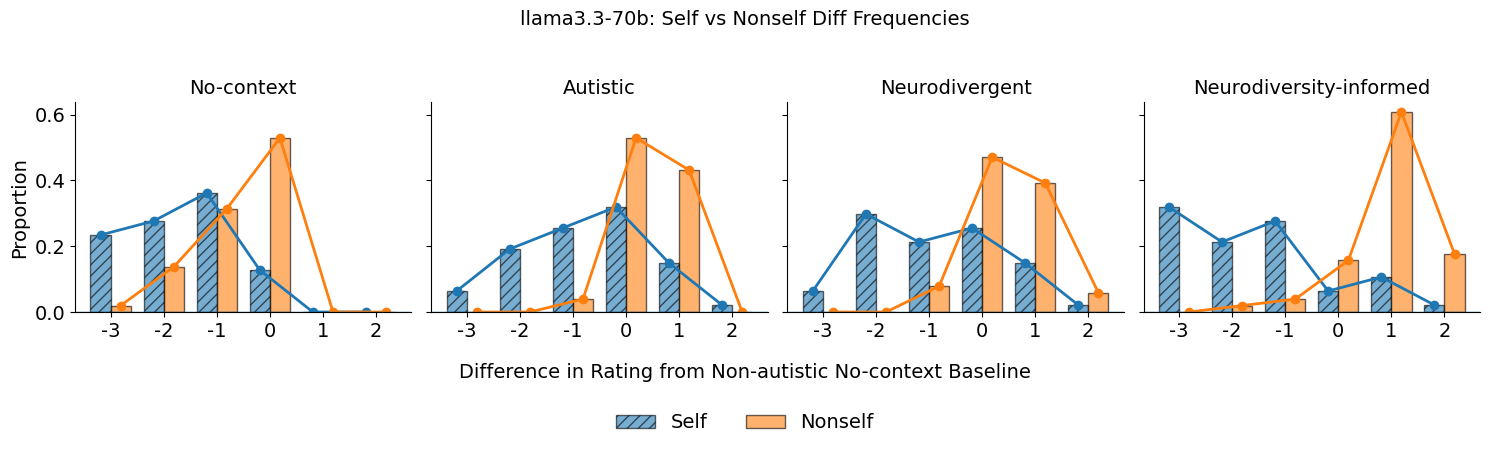

In [206]:
compute_self_nonself_means(metrics, datasets, source_tags)

In [270]:
from itertools import combinations
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import pandas as pd

metrics = ['hireability', 'dating', 'admission']
datasets = ['indirect']
source_tags = ['indirect']


def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""


def indirect_check(metrics, datasets, source_tags, random_state=42):
    rows = []

    excluded_models = {"llama3.2-1b", "sonnet4.5", "haiku4.5"}

    for metric in metrics:
        for i in range(len(datasets)):
            dataset = datasets[i]
            source_tag = source_tags[i]

            task, jobs_file, dataset_name, source_map = task_metadata(metric, dataset, source_tag)

            df = pd.read_csv(jobs_file)
            df = df[~df["model"].isin(excluded_models)].copy()

            clean_df = add_clean(df)
            analysis_df = drop_incomplete(clean_df)

            merged = calculate_differences(analysis_df, source_map, "no-context", "clean").copy()
            merged["task"] = task

            for (task_name, cond, model), group in merged.groupby(["task", "condition", "model"]):
                # extract labels present in this subset
                labels = sorted(group["label"].dropna().unique())

                # compare every pair of labels
                for label1, label2 in combinations(labels, 2):
                    g1 = group[group["label"] == label1]["diff"].dropna()
                    g2 = group[group["label"] == label2]["diff"].dropna()

                    n1 = len(g1)
                    n2 = len(g2)

                    if n1 == 0 or n2 == 0:
                        continue

                    n = min(n1, n2)

                    g1_bal = g1.sample(n=n, random_state=random_state) if n1 > n else g1
                    g2_bal = g2.sample(n=n, random_state=random_state) if n2 > n else g2

                    test = ttest_ind(g1_bal, g2_bal, equal_var=False)
                    p_val = test.pvalue

                    rows.append({
                        "task": task_name,
                        "condition": cond,
                        "model": model,
                        "label_1": label1,
                        "label_2": label2,
                        "comparison": f"{label1} vs {label2}",
                        "n_per_group": n,
                        "mean_label_1": g1_bal.mean(),
                        "mean_label_2": g2_bal.mean(),
                        "mean_diff": g1_bal.mean() - g2_bal.mean(),
                        "p_value": p_val,
                    })

    result = pd.DataFrame(rows)

    if result.empty:
        return result

    # FDR correction across all pairwise tests
    result["p_adj"] = multipletests(result["p_value"], method="fdr_bh")[1]
    result["sig"] = result["p_adj"].apply(p_to_stars)

    # ordering + labels
    task_order = ["hireability-ratings", "dating-ratings", "admission-ratings"]
    condition_order = ["no-context", "autistic", "neurodivergent", "neurodiversity-informed"]
    cond_map = {
        "no-context": "NC",
        "autistic": "A",
        "neurodivergent": "N",
        "neurodiversity-informed": "NDI"
    }

    result["task"] = pd.Categorical(result["task"], categories=task_order, ordered=True)
    result["condition"] = pd.Categorical(result["condition"], categories=condition_order, ordered=True)

    result = result.sort_values(
        ["task", "condition", "model", "label_1", "label_2"]
    ).copy()

    result["condition_short"] = result["condition"].map(cond_map)

    return result

In [287]:
result_indirect = indirect_check(metrics, datasets, source_tags, random_state=42)
print((result_indirect["p_adj"] < 0.05).mean())
print((result_indirect["mean_diff"] > 0).mean())
print(result_indirect.groupby("condition")["mean_diff"].mean())
print(result_indirect.groupby("comparison")["mean_diff"].mean())




0.10185185185185185
0.42824074074074076
condition
no-context                -0.133845
autistic                  -0.014355
neurodivergent             0.004736
neurodiversity-informed   -0.025775
Name: mean_diff, dtype: float64
comparison
existential vs knowledge      -0.201279
existential vs permission      0.030655
existential vs verification   -0.159358
knowledge vs permission        0.229464
knowledge vs verification      0.039616
permission vs verification    -0.192956
Name: mean_diff, dtype: float64


/var/folders/30/7js64q2522sb_sszvtx_30_00000gn/T/ipykernel_2409/1137386018.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(result_indirect.groupby("condition")["mean_diff"].mean())


In [295]:
metrics = ['hireability', 'dating','admission']
datasets = ['bluntness', 'figurative', 'indirect']
source_tags = ['blunt', 'figurative', 'indirect']

In [74]:
def build_full_dataset(metrics, datasets, source_tags):
    dfs = []

    for dataset, source_tag in zip(datasets, source_tags):
        for metric in metrics:
            task, jobs_file, dataset_name, source_map = task_metadata(metric, dataset, source_tag)
            df = pd.read_csv(jobs_file).copy()

            # add metadata
            df["task"] = task                      # e.g., hireability-ratings
            df["metric"] = metric                  # cleaner version if needed
            df["dataset"] = dataset_name           # bluntness / figurative / indirect
            df["source_tag"] = source_tag          # blunt / figurative / indirect

            dfs.append(df)

    full_df = pd.concat(dfs, ignore_index=True)

    return full_df

def extract_rating(output):
    if pd.isna(output):
        return np.nan

    text = re.sub(r"<think>.*?</think>", "", str(output), flags=re.DOTALL).strip()
    matches = re.findall(r"\b([1-5])\b", text)

    return float(matches[-1]) if matches else np.nan


def clean_full_df(full_df):
    df = full_df.copy()

    df["clean"] = df["output"].apply(extract_rating)

    if "error" in df.columns:
        df["has_error"] = df["error"].notna() & (df["error"].astype(str).str.strip() != "")
    else:
        df["has_error"] = False

    df = df[~df["has_error"]].copy()
    df = df[df["clean"].notna()].copy()

    excluded_models = {"llama3.2-1b", "sonnet4.5", "haiku4.5"}
    df = df[~df["model"].isin(excluded_models)].copy()

    df["condition"] = (
        df["condition"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace("_", "-", regex=False)
    )

    df["model"] = df["model"].astype(str).str.strip()

    if "label" in df.columns:
        df["label"] = df["label"].astype(str).str.strip().str.lower()

    key_cols = ["task", "dataset", "source_file", "row_id", "model", "condition"]
    if "label" in df.columns:
        key_cols.append("label")

    df = df.drop_duplicates(subset=key_cols, keep="first").reset_index(drop=True)

    return df

def build_analysis_df(full_df, source_tags):
    rows = []

    for dataset, source_tag in zip(datasets, source_tags):
        df = full_df[full_df["dataset"] == dataset].copy()

        aut_file = f"{source_tag}_aut.json"
        non_file = f"{source_tag}_non_aut.json"

        aut = df[df["source_file"] == aut_file].copy()
        non_base = df[
            (df["source_file"] == non_file) &
            (df["condition"] == "no-context")
        ].copy()

        aut = aut.rename(columns={"clean": "aut_rating"})
        non_base = non_base.rename(columns={"clean": "non_base_rating"})

        merge_cols = ["task", "row_id", "model"]
        if "label" in df.columns:
            merge_cols.append("label")

        merged = aut.merge(
            non_base[merge_cols + ["non_base_rating"]],
            on=merge_cols,
            how="inner"
        )

        merged["diff"] = merged["aut_rating"] - merged["non_base_rating"]
        merged["dataset"] = dataset

        rows.append(merged)

    return pd.concat(rows, ignore_index=True)


In [75]:
full_df = build_full_dataset(metrics, datasets, source_tags)
full_df = clean_full_df(full_df)
analysis_df = build_analysis_df(full_df, source_tags)
# print(analysis_df.shape)
# print(analysis_df["condition"].value_counts())

In [76]:
# baseline_table = (
#     analysis_df[analysis_df["condition"] == "no-context"]
#     .groupby(["dataset", "task"])["diff"]
#     .agg(
#         mu_delta="mean",
#         mean_abs_delta=lambda x: x.abs().mean(),
#         pct_neg=lambda x: (x < 0).mean(),
#         p10=lambda x: x.quantile(0.10),
#         p90=lambda x: x.quantile(0.90),
#         median="median",
#         n="count",
#     )
#     .reset_index()
# )


In [77]:
print(
    analysis_df.groupby(["dataset", "condition"])["diff"]
    .mean()
    .reset_index()
)

       dataset                condition      diff
0    bluntness                 autistic -0.090757
1    bluntness           neurodivergent -0.158421
2    bluntness  neurodiversity-informed -0.357778
3    bluntness               no-context -0.880913
4   figurative                 autistic -0.395775
5   figurative           neurodivergent -0.228333
6   figurative  neurodiversity-informed -0.190000
7   figurative               no-context -0.750279
8     indirect                 autistic -0.318333
9     indirect           neurodivergent -0.323333
10    indirect  neurodiversity-informed -0.165556
11    indirect               no-context -0.850306


In [318]:
print(
    analysis_df.groupby(["model", "condition"])["diff"]
    .mean()
    .reset_index()
)

              model                condition      diff
0       deepseek-r1                 autistic -0.410000
1       deepseek-r1           neurodivergent -0.364444
2       deepseek-r1  neurodiversity-informed -0.353333
3       deepseek-r1               no-context -0.837778
4   gemini2.5-flash                 autistic -0.073333
5   gemini2.5-flash           neurodivergent -0.085556
6   gemini2.5-flash  neurodiversity-informed -0.002222
7   gemini2.5-flash               no-context -1.344444
8             gpt4o                 autistic -0.205784
9             gpt4o           neurodivergent -0.132222
10            gpt4o  neurodiversity-informed -0.105556
11            gpt4o               no-context -0.361607
12       gpt4o-mini                 autistic -0.500000
13       gpt4o-mini           neurodivergent -0.476667
14       gpt4o-mini  neurodiversity-informed -0.582222
15       gpt4o-mini               no-context -0.729911
16           gpt5.2                 autistic -0.427617
17        

In [322]:
import statsmodels.formula.api as smf

# reg_df = analysis_df[analysis_df["condition"] != "no-context"].copy()
reg_df = analysis_df.copy()

model = smf.ols(
    "diff ~ C(dataset)*C(condition) + C(dataset)*C(task) + C(condition)*C(task) + C(model)",
    data=analysis_df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   diff   R-squared:                       0.150
Model:                            OLS   Adj. R-squared:                  0.149
Method:                 Least Squares   F-statistic:                     173.3
Date:                Sat, 11 Apr 2026   Prob (F-statistic):               0.00
Time:                        20:44:01   Log-Likelihood:                -26084.
No. Observations:               21582   AIC:                         5.221e+04
Df Residuals:                   21559   BIC:                         5.240e+04
Df Model:                          22                                         
Covariance Type:            nonrobust                                         
                                                                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

### New Analysis

In [148]:
metrics = ['hireability', 'dating','admission']
datasets = ['bluntness', 'figurative', 'indirect'] 
source_tags = ['blunt', 'figurative', 'indirect']

#just load data from all files
def build_full_dataset(metrics, datasets, source_tags):
    dfs = []

    for dataset, source_tag in zip(datasets, source_tags):
        for metric in metrics:
            task, jobs_file, dataset_name, source_map = task_metadata(metric, dataset, source_tag)
            df = pd.read_csv(jobs_file).copy()

            # add metadata
            df["task"] = task                      # e.g., hireability-ratings
            df["metric"] = metric                  # cleaner version if needed
            df["dataset"] = dataset_name           # bluntness / figurative / indirect
            dfs.append(df)

    full_df = pd.concat(dfs, ignore_index=True)

    return full_df

def extract_rating(output):
    if pd.isna(output):
        return np.nan

    text = str(output)
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.DOTALL)
    matches = re.findall(r"\b([1-5])\b", text)

    if matches:
        return float(matches[-1])
    return np.nan


def clean_full_df(full_df):
    df = full_df.copy()

    df["clean"] = df["output"].apply(extract_rating)

    if "error" in df.columns:
        df = df[df["error"].isna() | (df["error"].astype(str).str.strip() == "")]
    df = df[df["clean"].notna()]

    excluded_models = ["llama3.2-1b", "sonnet4.5", "haiku4.5"]
    df = df[~df["model"].isin(excluded_models)]

    df["condition"] = (
        df["condition"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace("_", "-", regex=False)
    )

    df["model"] = df["model"].astype(str).str.strip()

    # # standardize dataset names
    # df["dataset"] = df["dataset"].astype(str).str.strip().str.lower()
    # df["dataset"] = df["dataset"].replace({
    #     "bluntness": "blunt"
    # })

    if "label" in df.columns:
        df["label"] = df["label"].astype(str).str.strip().str.lower()

    keep_cols = ["row_id", "source_file", "label", "dataset", "task", "condition", "model", "clean"]
    keep_cols = [col for col in keep_cols if col in df.columns]
    df = df[keep_cols]

    key_cols = ["task", "dataset", "source_file", "row_id", "model", "condition"]
    if "label" in df.columns:
        key_cols.append("label")

    df = df.drop_duplicates(subset=key_cols).reset_index(drop=True)

    return df

In [189]:
def build_analysis_df(full_df, datasets, source_tags):
    rows = []

    for dataset, source_tag in zip(datasets, source_tags):
        df = full_df[full_df["dataset"] == dataset].copy()

        aut_file = f"{source_tag}_aut.json"
        non_file = f"{source_tag}_non_aut.json"

        aut = df[df["source_file"] == aut_file].copy()
        non = df[df["source_file"] == non_file].copy()

        # rename for pairing
        aut = aut.rename(columns={"clean": "clean"})
        non = non.rename(columns={"clean": "rating_non"})

        merge_cols = ["task", "row_id", "model", "condition"]
        if "label" in df.columns:
            merge_cols.append("label")

        # pair aut + non
        paired = aut.merge(
            non[merge_cols + ["rating_non"]],
            on=merge_cols,
            how="inner"
        )

        paired["dialogue_type"] = dataset

        # --- get non-aut no-context baseline ---
        key_cols = ["task", "row_id", "model"]
        if "label" in paired.columns:
            key_cols.append("label")

        non_nc = (
            paired[paired["condition"] == "no-context"][key_cols + ["rating_non"]]
            .rename(columns={"rating_non": "non_aut_no_context"})
        )

        paired = paired.merge(non_nc, on=key_cols, how="left")

        # --- compute diff ---
        paired["diff"] = paired["clean"] - paired["non_aut_no_context"]

        # --- keep only what you need ---
        keep_cols = [
            "row_id",
            "label",
            "task",
            "dialogue_type",
            "condition",
            "model",
            "clean",
            "diff"
        ]
        keep_cols = [c for c in keep_cols if c in paired.columns]

        paired = paired[keep_cols]

        rows.append(paired)

    return pd.concat(rows, ignore_index=True)

In [190]:
full_df = build_full_dataset(metrics, datasets, source_tags)
full_df = clean_full_df(full_df)
analysis_df = build_analysis_df(full_df, datasets, source_tags)

print(analysis_df.columns)
print(len(analysis_df))
# print(analysis_df[analysis_df["dialogue_type"]=="bluntness"])


Index(['row_id', 'label', 'task', 'dialogue_type', 'condition', 'model',
       'clean', 'diff'],
      dtype='object')
21576


#### Baseline Bias Table

In [191]:
def baseline_bias_table(df):
    # baseline only
    df = df[df["condition"] == "no-context"].copy()

    rows = []

    for (dialogue, task), g in df.groupby(["dialogue_type", "task"]):
        s = g["diff"].dropna()

        mu = s.mean()
        median = s.median()
        p10 = s.quantile(0.10)
        p90 = s.quantile(0.90)
        pct_neg = (s < 0).mean() * 100

        # Wilcoxon (keep zeros)
        if len(s) == 0 or (s == 0).all():
            p = np.nan
        else:
            try:
                _, p = wilcoxon(s, zero_method="zsplit")
            except:
                p = np.nan

        rows.append({
            "Dialogue": dialogue,
            "Task": task,
            "μΔ": round(mu, 2),
            "Median": round(median, 2),
            "P10": round(p10, 2),
            "P90": round(p90, 2),
            "% Negative": round(pct_neg, 1),
            "p": "< .001" if pd.notna(p) and p < 0.001 else round(p, 3)
        })

    out = pd.DataFrame(rows)

    # ordering (keep bluntness)
    dialogue_order = ["bluntness", "figurative", "indirect"]
    task_order = ["hireability-ratings", "dating-ratings", "admission-ratings"]

    out["Dialogue"] = pd.Categorical(out["Dialogue"], categories=dialogue_order, ordered=True)
    out["Task"] = pd.Categorical(out["Task"], categories=task_order, ordered=True)

    out = out.sort_values(["Dialogue", "Task"]).reset_index(drop=True)

    return out

In [192]:
baseline_table = baseline_bias_table(analysis_df)
baseline_table

,Dialogue,Task,μΔ,Median,P10,P90,% Negative,p
0,bluntness,hireability-ratings,-0.79,-1.0,-2.0,0.0,55.4,< .001
1,bluntness,dating-ratings,-1.07,-1.0,-2.0,0.0,75.3,< .001
2,bluntness,admission-ratings,-0.78,-1.0,-2.0,0.0,56.7,< .001
3,figurative,hireability-ratings,-1.08,-1.0,-2.0,0.0,70.7,< .001
4,figurative,dating-ratings,-0.60,-1.0,-2.0,1.0,51.8,< .001
5,figurative,admission-ratings,-0.57,-1.0,-2.0,1.0,51.0,< .001
6,indirect,hireability-ratings,-1.22,-1.0,-2.0,0.0,78.6,< .001
7,indirect,dating-ratings,-0.50,0.0,-1.0,0.0,41.8,< .001
8,indirect,admission-ratings,-0.83,-1.0,-2.0,0.0,61.8,< .001


### Prompt Effect

Index(['row_id', 'label', 'task', 'dialogue_type', 'condition', 'model',
       'clean', 'diff'],
      dtype='object')
21576


/var/folders/30/7js64q2522sb_sszvtx_30_00000gn/T/ipykernel_2092/2187913283.py:85: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(


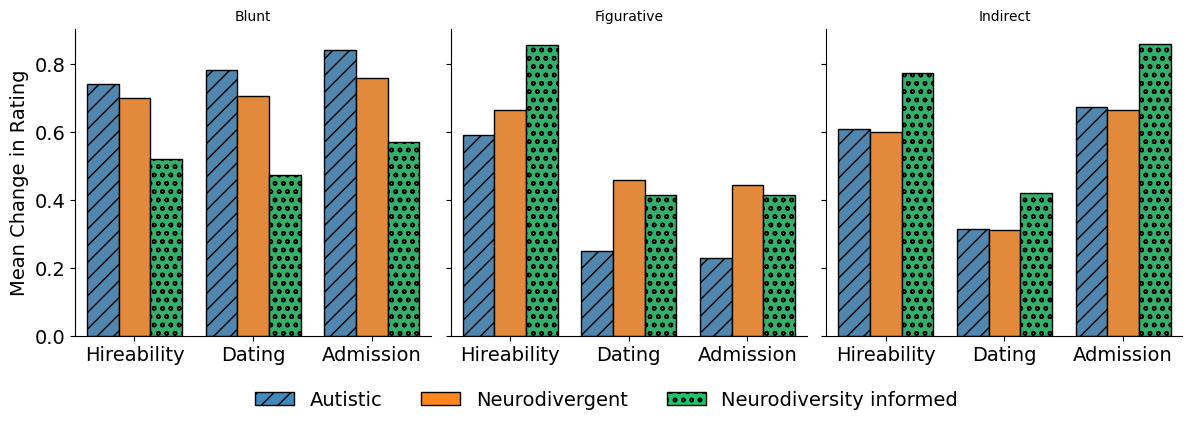

In [237]:
full_df = build_full_dataset(metrics, datasets, source_tags)
full_df = clean_full_df(full_df)
analysis_df = build_analysis_df(full_df, datasets, source_tags)

print(analysis_df.columns)
print(len(analysis_df))
# print(analysis_df[analysis_df["dialogue_type"]=="bluntness"])



def add_delta_aut(df):
    df = df.copy()

    # baseline (no-context) autistic ratings
    base = df[df["condition"] == "no-context"][
        ["row_id", "model", "task", "dialogue_type", "clean"]
    ].rename(columns={"clean": "aut_base"})

    # merge baseline back
    df = df.merge(
        base,
        on=["row_id", "model", "task", "dialogue_type"],
        how="left"
    )

    # compute delta
    df["delta_aut"] = df["clean"] - df["aut_base"]

    return df



def plot_prompt_effects_aut_only(analysis_df, palette):
    df = analysis_df.copy()
    df = df[df["condition"] != "no-context"].copy()

    plot_df = (
        df.groupby(["dialogue_type", "task", "condition"], as_index=False)["delta_aut"]
        .mean()
        .rename(columns={"delta_aut": "mean_shift"})
    )

    plot_df["task"] = (
        plot_df["task"].astype(str)
        .str.replace("-ratings", "", regex=False)
        .str.strip().str.lower()
        .replace({
            "hireability": "Hireability",
            "dating": "Dating",
            "admission": "Admission",
        })
    )

    plot_df["dialogue_type"] = (
        plot_df["dialogue_type"].astype(str)
        .str.strip().str.lower()
        .replace({
            "bluntness": "Blunt",
            "blunt": "Blunt",
            "figurative": "Figurative",
            "indirect": "Indirect",
        })
    )

    plot_df["condition"] = (
        plot_df["condition"].astype(str)
        .str.strip().str.lower()
        .replace({
            "autistic": "Autistic",
            "neurodivergent": "Neurodivergent",
            "neurodiversity-informed": "Neurodiversity informed",
        })
    )

    task_order = ["Hireability", "Dating", "Admission"]
    dialogue_order = ["Blunt", "Figurative", "Indirect"]
    condition_order = ["Autistic", "Neurodivergent", "Neurodiversity informed"]

    hatches = {
        "Autistic": "//",
        "Neurodivergent": "",
        "Neurodiversity informed": "oo",
    }

    g = sns.catplot(
        data=plot_df,
        kind="bar",
        x="task",
        y="mean_shift",
        hue="condition",
        hue_order=condition_order,
        order=task_order,
        col="dialogue_type",
        col_order=dialogue_order,
        palette=palette,
        ci=None,
        height=4,
        aspect=1,
    )

    g.set_titles("{col_name}")

    for ax in g.axes.flat:
        for bars, cond in zip(ax.containers, condition_order):
            for bar in bars:
                bar.set_hatch(hatches[cond])
                bar.set_edgecolor("black")
        ax.set_xlabel("")
        ax.set_ylabel("Mean Change in Rating", fontsize=14)
        ax.tick_params(axis="both", labelsize=14)

    legend_patches = [
        mpatches.Patch(
            facecolor=palette[c],
            hatch=hatches[c],
            edgecolor="black",
            label=c
        )
        for c in condition_order
    ]

    if g._legend is not None:
        g._legend.remove()

    g.fig.legend(
        handles=legend_patches,
        loc="lower center",
        bbox_to_anchor=(0.43, -0.08),
        ncol=3,
        frameon=False,
        fontsize=14,
    )

    plt.show()


analysis_df = add_delta_aut(analysis_df)
plot_prompt_effects_aut_only(
    analysis_df,
    palette={
        "Autistic": "#418ABE",
        "Neurodivergent": "#FF871F",
        "Neurodiversity informed": "#21C468",
    }
)


In [238]:
from scipy.stats import wilcoxon
import pandas as pd
import itertools


def pairwise_condition_tests(df):
    df = df[df["condition"] != "no-context"].copy()

    results = []

    conditions = df["condition"].unique()

    for (dialogue, task), g in df.groupby(["dialogue_type", "task"]):

        # pivot: rows = (row_id, model), columns = condition
        pivot = g.pivot_table(
            index=["row_id", "model"],
            columns="condition",
            values="delta_aut"
        )
        
        #print(pivot.notna().mean())

        for c1, c2 in itertools.combinations(conditions, 2):
            if c1 not in pivot.columns or c2 not in pivot.columns:
                continue

            diff = (pivot[c1] - pivot[c2]).dropna()

            if len(diff) == 0 or (diff == 0).all():
                p = None
            else:
                try:
                    _, p = wilcoxon(diff, zero_method="zsplit")
                except:
                    p = None

            results.append({
                "dialogue_type": dialogue,
                "task": task,
                "cond1": c1,
                "cond2": c2,
                "p": p
            })

    return pd.DataFrame(results)


pairwise_df = pairwise_condition_tests(analysis_df)

def summarize_pairwise(df):
    rows = []

    for (dialogue, task), g in df.groupby(["dialogue_type", "task"]):
        row = {
            "Dialogue": dialogue,
            "Task": task
        }

        def get_star(c1, c2):
            r = g[(g["cond1"] == c1) & (g["cond2"] == c2)]
            return r["star"].values[0] if not r.empty else ""

        row["A vs ND"] = get_star("autistic", "neurodivergent")
        row["A vs NDI"] = get_star("autistic", "neurodiversity-informed")
        row["ND vs NDI"] = get_star("neurodivergent", "neurodiversity-informed")

        rows.append(row)

    return pd.DataFrame(rows)


def p_to_star(p):
    if p is None or pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""

pairwise_df["star"] = pairwise_df["p"].apply(p_to_star)

summary_table = summarize_pairwise(pairwise_df)
summary_table

,Dialogue,Task,A vs ND,A vs NDI,ND vs NDI
0,bluntness,admission-ratings,**,***,***
1,bluntness,dating-ratings,**,***,***
2,bluntness,hireability-ratings,,***,***
3,figurative,admission-ratings,***,***,
4,figurative,dating-ratings,***,***,
5,figurative,hireability-ratings,***,***,***
6,indirect,admission-ratings,,***,***
7,indirect,dating-ratings,,***,***
8,indirect,hireability-ratings,,***,***


Index(['row_id', 'label', 'task', 'dialogue_type', 'condition', 'model',
       'clean', 'diff'],
      dtype='object')
21576
    condition  clean  diff
0  no-context    3.0   0.0
1  no-context    3.0  -1.0
2  no-context    3.0   0.0
3  no-context    3.0   0.0
4  no-context    3.0   0.0


/var/folders/30/7js64q2522sb_sszvtx_30_00000gn/T/ipykernel_2092/3082449910.py:86: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  g = sns.catplot(


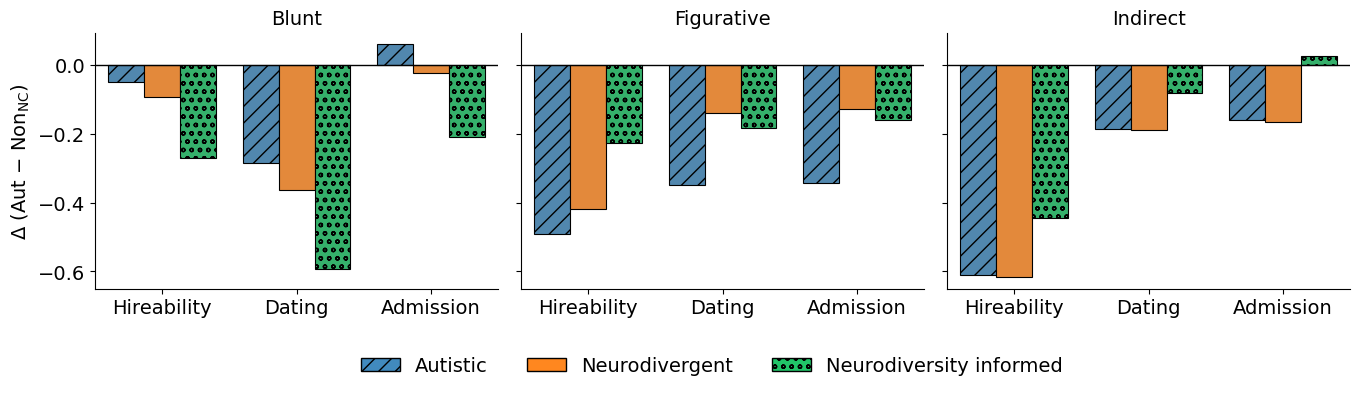

In [242]:
full_df = build_full_dataset(metrics, datasets, source_tags)
full_df = clean_full_df(full_df)
analysis_df = build_analysis_df(full_df, datasets, source_tags)

print(analysis_df.columns)
print(len(analysis_df))
# print(analysis_df[analysis_df["dialogue_type"]=="bluntness"])


def plot_residual_gap_from_current_df(analysis_df):
    df = analysis_df.copy()

    # keep only prompted conditions
    df = df[df["condition"] != "no-context"].copy()

    # aggregate mean gap
    plot_df = (
        df.groupby(["task", "dialogue_type", "condition"], as_index=False)["diff"]
        .mean()
        .rename(columns={"diff": "mean_gap"})
    )

    # clean labels
    plot_df["task"] = (
        plot_df["task"]
        .astype(str)
        .str.replace("-ratings", "", regex=False)
        .str.strip()
        .str.lower()
        .replace({
            "hireability": "Hireability",
            "dating": "Dating",
            "admission": "Admission",
            "admissions": "Admissions",
        })
    )

    plot_df["dialogue_type"] = (
        plot_df["dialogue_type"]
        .astype(str)
        .str.replace("-", " ", regex=False)
        .str.strip()
        .str.lower()
        .replace({
            "bluntness": "Blunt",
            "blunt": "Blunt",
            "figurative": "Figurative",
            "indirect": "Indirect",
        })
    )

    plot_df["condition"] = (
        plot_df["condition"]
        .astype(str)
        .str.replace("-", " ", regex=False)
        .str.strip()
        .str.lower()
        .replace({
            "autistic": "Autistic",
            "neurodivergent": "Neurodivergent",
            "neurodiversity informed": "Neurodiversity informed",
            "neurodiversity-informed": "Neurodiversity informed",
        })
    )

    task_order = ["Hireability", "Dating", "Admission", "Admissions"]
    task_order = [t for t in task_order if t in plot_df["task"].unique()]

    dialogue_order = ["Blunt", "Figurative", "Indirect"]
    dialogue_order = [d for d in dialogue_order if d in plot_df["dialogue_type"].unique()]

    condition_order = ["Autistic", "Neurodivergent", "Neurodiversity informed"]

    palette = {
        "Autistic": "#418ABE",
        "Neurodivergent": "#FF871F",
        "Neurodiversity informed": "#21C468"
    }

    hatches = {
        "Autistic": "//",
        "Neurodivergent": "",
        "Neurodiversity informed": "oo"
    }

    g = sns.catplot(
        data=plot_df,
        kind="bar",
        x="task",
        y="mean_gap",
        hue="condition",
        hue_order=condition_order,
        col="dialogue_type",
        col_order=dialogue_order,
        order=task_order,
        palette=palette,
        ci=None,
        height=4,
        aspect=1
    )

    g.set_titles("{col_name}")

    for ax in g.axes.flat:
        ax.axhline(0, color="black", linewidth=1)

        for bars, cond in zip(ax.containers, condition_order):
            for bar in bars:
                bar.set_hatch(hatches[cond])
                bar.set_edgecolor("black")
                bar.set_linewidth(0.8)

        ax.set_xlabel("")
        ax.set_ylabel(r"$\Delta$ (Aut $-$ Non$_{\mathrm{NC}}$)", fontsize=14)
        ax.tick_params(axis="both", labelsize=14)

    legend_patches = [
        mpatches.Patch(
            facecolor=palette[c],
            hatch=hatches[c],
            edgecolor="black",
            label=c
        )
        for c in condition_order
    ]

    if g._legend is not None:
        g._legend.remove()

    g.fig.legend(
        handles=legend_patches,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.08),
        ncol=3,
        frameon=False,
        fontsize=14
    )

    for ax in g.axes.flat:
        ax.set_title(ax.get_title(), fontsize=14)

    plt.subplots_adjust(top=0.82, bottom=0.18, right=0.95)
    plt.show()

plot_residual_gap_from_current_df(analysis_df)

### Models

In [262]:
full_df = build_full_dataset(metrics, datasets, source_tags)
full_df = clean_full_df(full_df)
analysis_df = build_analysis_df(full_df, datasets, source_tags)

print(analysis_df.columns)
print(len(analysis_df))




Index(['row_id', 'label', 'task', 'dialogue_type', 'condition', 'model',
       'clean', 'diff'],
      dtype='object')
21576


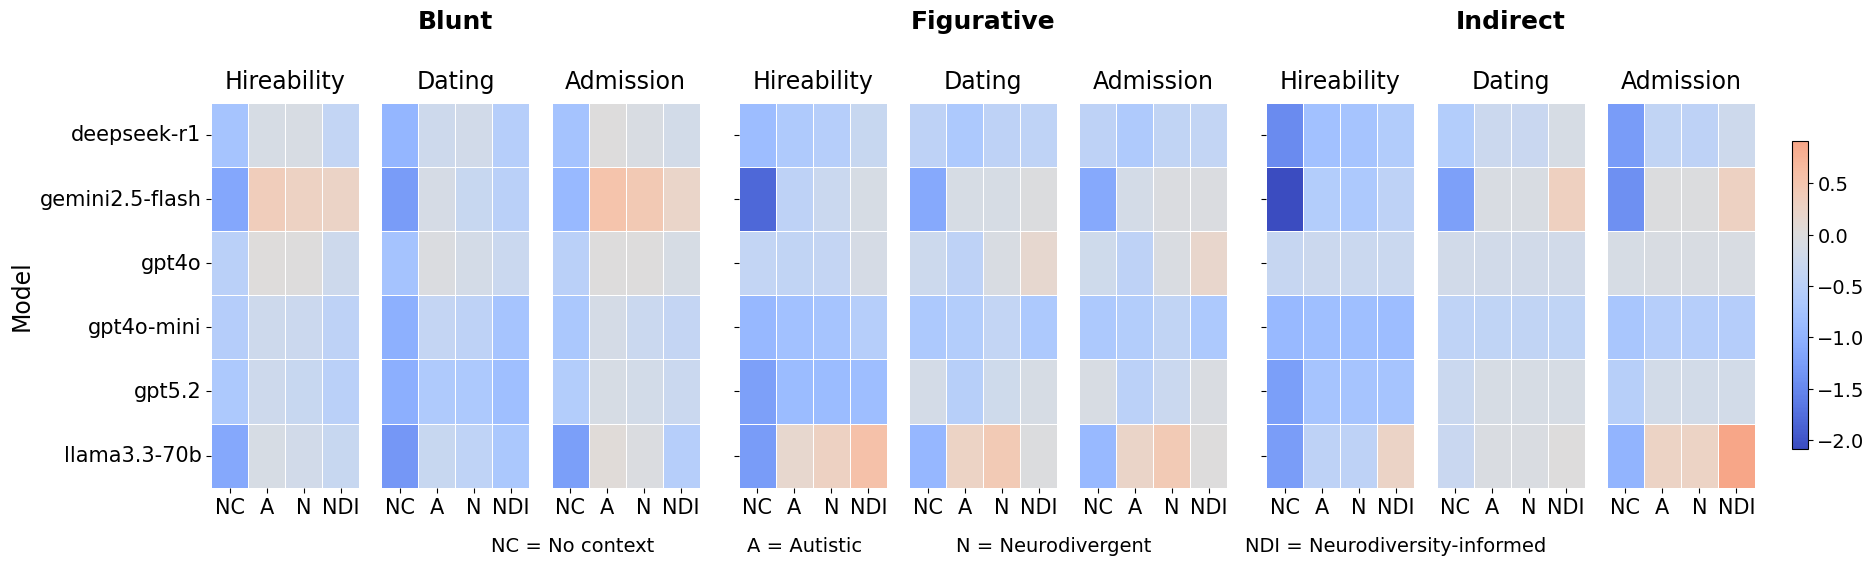

In [263]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import gridspec

def plot_model_heatmap_from_analysis_df(analysis_df):
    df = analysis_df.copy()

    # aggregate mean gap per model/task/dialogue/condition
    model_df = (
        df.groupby(["model", "task", "dialogue_type", "condition"], as_index=False)["diff"]
        .mean()
        .rename(columns={"diff": "mean_gap"})
    )

    # clean labels
    model_df["task"] = (
        model_df["task"]
        .astype(str)
        .str.replace("-ratings", "", regex=False)
        .str.strip()
        .str.lower()
        .replace({
            "hireability": "Hireability",
            "dating": "Dating",
            "admission": "Admission",
            "admissions": "Admissions"
        })
    )

    model_df["condition"] = (
        model_df["condition"]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            "no-context": "NC",
            "autistic": "A",
            "neurodivergent": "N",
            "neurodiversity-informed": "NDI",
            "neurodiversity informed": "NDI"
        })
    )

    model_df["dialogue_type"] = (
        model_df["dialogue_type"]
        .astype(str)
        .str.strip()
        .str.lower()
        .replace({
            "bluntness": "Blunt",
            "blunt": "Blunt",
            "figurative": "Figurative",
            "indirect": "Indirect"
        })
    )

    task_order = ["Hireability", "Dating", "Admission", "Admissions"]
    task_order = [t for t in task_order if t in model_df["task"].unique()]

    condition_order = ["NC", "A", "N", "NDI"]
    condition_order = [c for c in condition_order if c in model_df["condition"].unique()]

    dialogue_order = ["Blunt", "Figurative", "Indirect"]
    dialogue_order = [d for d in dialogue_order if d in model_df["dialogue_type"].unique()]

    # keep your displayed order if you want
    preferred_model_order = [
        "deepseek-r1",
        "gemini2.5-flash",
        "gpt4o",
        "gpt4o-mini",
        "gpt5.2",
        "llama3.3-70b"
    ]
    model_order = [m for m in preferred_model_order if m in model_df["model"].unique()]
    leftovers = [m for m in sorted(model_df["model"].unique()) if m not in model_order]
    model_order += leftovers

    vmin = model_df["mean_gap"].min()
    vmax = model_df["mean_gap"].max()

    fig = plt.figure(figsize=(24, 5))
    outer = gridspec.GridSpec(1, len(dialogue_order), wspace=0.08)

    last_hm = None

    for i, dialogue in enumerate(dialogue_order):
        sub = model_df[model_df["dialogue_type"] == dialogue].copy()

        inner = gridspec.GridSpecFromSubplotSpec(
            1, len(task_order),
            subplot_spec=outer[i],
            wspace=0.15
        )

        task_axes = []

        for j, task in enumerate(task_order):
            ax = plt.Subplot(fig, inner[j])
            fig.add_subplot(ax)
            task_axes.append(ax)

            task_sub = sub[sub["task"] == task].copy()

            pivot = task_sub.pivot_table(
                index="model",
                columns="condition",
                values="mean_gap",
                aggfunc="mean"
            )

            pivot = pivot.reindex(index=model_order, columns=condition_order)

            hm = sns.heatmap(
                pivot,
                ax=ax,
                cmap="coolwarm",
                center=0,
                vmin=vmin,
                vmax=vmax,
                cbar=False,
                linewidths=0.5,
                linecolor="white"
            )
            last_hm = hm

            ax.set_title(task, fontsize=17, pad=10)
            ax.set_xlabel("")
            ax.set_xticklabels(condition_order, rotation=0, ha="center", fontsize=15)

            if i == 0 and j == 0:
                ax.set_ylabel("Model", fontsize=17)
                ax.tick_params(axis="y", labelsize=15)
            elif j == 0:
                ax.set_ylabel("")
                ax.tick_params(axis="y", labelleft=False)
            else:
                ax.set_ylabel("")
                ax.set_yticklabels([])
                ax.tick_params(axis="y", left=False)

        task_axes[len(task_axes)//2].text(
            0.5, 1.18, dialogue,
            transform=task_axes[len(task_axes)//2].transAxes,
            ha="center", va="bottom",
            fontsize=18, fontweight="bold"
        )

    cbar = fig.colorbar(last_hm.collections[0], ax=fig.axes, shrink=0.8, pad=0.02)
    cbar.ax.tick_params(labelsize=14)

    legend_elements = [
        mpatches.Patch(facecolor='none', edgecolor='none', label='NC = No context'),
        mpatches.Patch(facecolor='none', edgecolor='none', label='A = Autistic'),
        mpatches.Patch(facecolor='none', edgecolor='none', label='N = Neurodivergent'),
        mpatches.Patch(facecolor='none', edgecolor='none', label='NDI = Neurodiversity-informed')
    ]

    fig.legend(
        handles=legend_elements,
        loc='lower center',
        bbox_to_anchor=(0.45, -0.06),
        ncol=4,
        frameon=False,
        fontsize=14
    )

    plt.show()
plot_model_heatmap_from_analysis_df(analysis_df)

In [264]:
from scipy.stats import kruskal
import pandas as pd

def model_effect_tests(df):
    results = []

    for (dialogue, task, cond), g in df.groupby(["dialogue_type", "task", "condition"]):
        groups = [
            sub["diff"].dropna().values
            for _, sub in g.groupby("model")
        ]

        # remove empty groups
        groups = [arr for arr in groups if len(arr) > 0]

        if len(groups) < 2:
            stat, p = None, None
        else:
            stat, p = kruskal(*groups)

        results.append({
            "dialogue_type": dialogue,
            "task": task,
            "condition": cond,
            "stat": stat,
            "p": p
        })

    return pd.DataFrame(results)

def p_to_star(p):
    if p is None or pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    return ""

def summarize_kw(df):
    out = df.copy()

    # convert condition names
    out["condition"] = out["condition"].replace({
        "no-context": "NC",
        "autistic": "A",
        "neurodivergent": "ND",
        "neurodiversity-informed": "NDI"
    })

    # pivot
    pivot = out.pivot_table(
        index=["dialogue_type", "task"],
        columns="condition",
        values="star",
        aggfunc="first"
    ).reset_index()

    # clean labels
    pivot["dialogue_type"] = pivot["dialogue_type"].replace({
        "bluntness": "Blunt",
        "figurative": "Figurative",
        "indirect": "Indirect"
    })

    pivot["task"] = pivot["task"].replace({
        "hireability-ratings": "Hireability",
        "dating-ratings": "Dating",
        "admission-ratings": "Admissions"
    })

    return pivot

model_test_df = model_effect_tests(analysis_df)
model_test_df["star"] = model_test_df["p"].apply(p_to_star)
kw_table = summarize_kw(model_test_df)
kw_table

condition,dialogue_type,task,A,NC,ND,NDI
0,Blunt,Admissions,***,***,***,***
1,Blunt,Dating,***,***,***,**
2,Blunt,Hireability,***,***,***,***
3,Figurative,Admissions,***,***,***,***
4,Figurative,Dating,***,***,***,***
5,Figurative,Hireability,***,***,***,***
6,Indirect,Admissions,***,***,***,***
7,Indirect,Dating,***,***,***,***
8,Indirect,Hireability,***,***,***,***


In [265]:
def get_model_means(analysis_df):
    return (
        analysis_df
        .groupby(["dialogue_type", "task", "model", "condition"], as_index=False)["diff"]
        .mean()
        .rename(columns={"diff": "mean_diff"})
    )

def model_extremes_table(model_df):
    df = model_df.copy()
    rows = []

    cond_map = {
        "no-context": "NC",
        "autistic": "A",
        "neurodivergent": "N",
        "neurodiversity-informed": "NDI"
    }

    grouped = df.groupby(["dialogue_type", "task"])

    for (dialogue, task), group in grouped:
        if group.empty:
            continue

        zero_row = group.loc[group["mean_diff"].abs().idxmin()]
        min_row = group.loc[group["mean_diff"].idxmin()]
        max_row = group.loc[group["mean_diff"].idxmax()]

        rows.append({
            "dialogue_type": dialogue,
            "task": task,

            "closest_model": zero_row["model"],
            "closest_diff": zero_row["mean_diff"],
            "closest_condition": cond_map.get(zero_row["condition"], zero_row["condition"]),

            "min_model": min_row["model"],
            "min_diff": min_row["mean_diff"],
            "min_condition": cond_map.get(min_row["condition"], min_row["condition"]),

            "max_model": max_row["model"],
            "max_diff": max_row["mean_diff"],
            "max_condition": cond_map.get(max_row["condition"], max_row["condition"]),
        })

    extremes = pd.DataFrame(rows)

    for col in ["closest_diff", "min_diff", "max_diff"]:
        extremes[col] = extremes[col].round(3)

    task_order = ["hireability-ratings", "dating-ratings", "admission-ratings"]

    extremes["task"] = pd.Categorical(
        extremes["task"],
        categories=task_order,
        ordered=True
    )

    extremes = extremes.sort_values(["dialogue_type", "task"]).reset_index(drop=True)
    
    return extremes

model_df = get_model_means(analysis_df)
extremes_df = model_extremes_table(model_df)
extremes_df

,dialogue_type,task,closest_model,closest_diff,closest_condition,min_model,min_diff,min_condition,max_model,max_diff,max_condition
0,bluntness,hireability-ratings,gpt4o,0.01,N,gemini2.5-flash,-1.15,NC,gemini2.5-flash,0.36,A
1,bluntness,dating-ratings,gpt4o,-0.04,A,llama3.3-70b,-1.33,NC,gpt4o,-0.04,A
2,bluntness,admission-ratings,deepseek-r1,0.00,A,llama3.3-70b,-1.25,NC,gemini2.5-flash,0.53,A
3,figurative,hireability-ratings,gemini2.5-flash,-0.10,NDI,gemini2.5-flash,-1.82,NC,llama3.3-70b,0.56,NDI
4,figurative,dating-ratings,gemini2.5-flash,-0.03,NDI,gemini2.5-flash,-1.11,NC,llama3.3-70b,0.42,N
5,figurative,admission-ratings,llama3.3-70b,0.00,NDI,gemini2.5-flash,-1.11,NC,llama3.3-70b,0.43,N
6,indirect,hireability-ratings,llama3.3-70b,0.25,NDI,gemini2.5-flash,-2.09,NC,llama3.3-70b,0.25,NDI
7,indirect,dating-ratings,llama3.3-70b,0.01,NDI,gemini2.5-flash,-1.23,NC,gemini2.5-flash,0.32,NDI
8,indirect,admission-ratings,gemini2.5-flash,-0.02,A,gemini2.5-flash,-1.42,NC,llama3.3-70b,0.91,NDI


### Blunt vs Non-blunt

In [269]:

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import pandas as pd

full_df = build_full_dataset(metrics, datasets, source_tags)
full_df = clean_full_df(full_df)
analysis_df = build_analysis_df(full_df, datasets, source_tags)

print(analysis_df.columns)
print(len(analysis_df))




def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""


def self_nonself_balanced(analysis_df, random_state=42):
    rows = []

    for (task, condition, model), group in analysis_df.groupby(["task", "condition", "model"]):
        g_self = group[group["label"] == "self"]["diff"].dropna()
        g_non = group[group["label"] == "nonself"]["diff"].dropna()

        n_self = len(g_self)
        n_non = len(g_non)

        if n_self == 0 or n_non == 0:
            continue

        n = min(n_self, n_non)

        if n_self > n:
            g_self = g_self.sample(n=n, random_state=random_state)
        if n_non > n:
            g_non = g_non.sample(n=n, random_state=random_state)

        test = ttest_ind(g_self, g_non, equal_var=False)

        rows.append({
            "task": task,
            "condition": condition,
            "model": model,
            "n_per_group": n,
            "mean_self": g_self.mean(),
            "mean_nonself": g_non.mean(),
            "mean_diff": g_self.mean() - g_non.mean(),
            "p_value": test.pvalue,
        })

    result = pd.DataFrame(rows)

    if result.empty:
        return result

    result["p_adj"] = multipletests(result["p_value"], method="fdr_bh")[1]
    result["sig"] = result["p_adj"].apply(p_to_stars)

    task_order = ["hireability-ratings", "dating-ratings", "admission-ratings"]
    condition_order = ["no-context", "autistic", "neurodivergent", "neurodiversity-informed"]
    cond_map = {
        "no-context": "NC",
        "autistic": "A",
        "neurodivergent": "N",
        "neurodiversity-informed": "NDI"
    }

    result["task"] = pd.Categorical(result["task"], categories=task_order, ordered=True)
    result["condition"] = pd.Categorical(result["condition"], categories=condition_order, ordered=True)

    result = result.sort_values(["task", "condition", "model"]).reset_index(drop=True)
    result["condition_short"] = result["condition"].map(cond_map)

    return result

Index(['row_id', 'label', 'task', 'dialogue_type', 'condition', 'model',
       'clean', 'diff'],
      dtype='object')
21576


In [278]:
full_df = build_full_dataset(metrics, datasets, source_tags)
full_df = clean_full_df(full_df)
analysis_df = build_analysis_df(full_df, datasets, source_tags)

result = self_nonself_balanced(analysis_df)
table = result.copy()

# create cell = mean_diff + stars
table["cell"] = table.apply(
    lambda row: f'{row["mean_diff"]:.2f}{p_to_stars(row["p_adj"])}',
    axis=1
)

# pivot to wide format
table = (
    table
    .pivot(index=["task", "condition"], columns="model", values="cell")
    .reset_index()
)

table


model,task,condition,deepseek-r1,gemini2.5-flash,gpt4o,gpt4o-mini,gpt5.2,llama3.3-70b
0,hireability-ratings,no-context,-0.71***,-0.53*,-0.90***,-0.77***,-0.83***,-1.00***
1,hireability-ratings,autistic,-0.20,-0.49,0.06,-0.49***,-0.23,-1.06***
2,hireability-ratings,neurodivergent,-0.22,-0.49,-0.02,-0.54***,-0.34*,-1.29***
3,hireability-ratings,neurodiversity-informed,-1.33***,-1.06***,-0.62***,-0.98***,-0.73***,-2.43***
4,dating-ratings,no-context,-0.49**,0.24,-0.53***,-0.76***,-0.51***,-0.57**
5,dating-ratings,autistic,-0.18,0.20,0.06,-0.65***,-0.24,-0.82***
6,dating-ratings,neurodivergent,-0.33*,0.24,-0.18,-0.82***,-0.41**,-0.96***
7,dating-ratings,neurodiversity-informed,-1.29***,-0.76***,-0.73***,-1.39***,-0.80***,-1.86***
8,admission-ratings,no-context,-0.63***,-0.92***,-0.86***,-0.43***,-0.76***,-0.86***
9,admission-ratings,autistic,-0.31*,-0.22,-0.02,-0.46***,-0.20,-0.94***


In [252]:
# import itertools
# from scipy.stats import mannwhitneyu

# def model_pairwise_tests(df):
#     rows = []

#     for (dialogue, task, cond), g in df.groupby(["dialogue_type", "task", "condition"]):
#         models = g["model"].unique()

#         for m1, m2 in itertools.combinations(models, 2):
#             s1 = g[g["model"] == m1]["diff"].dropna()
#             s2 = g[g["model"] == m2]["diff"].dropna()

#             if len(s1) == 0 or len(s2) == 0:
#                 p = None
#             else:
#                 _, p = mannwhitneyu(s1, s2, alternative="two-sided")

#             rows.append({
#                 "dialogue_type": dialogue,
#                 "task": task,
#                 "condition": cond,
#                 "model1": m1,
#                 "model2": m2,
#                 "p": p
#             })

#     return pd.DataFrame(rows)
# pairwise_model_df = model_pairwise_tests(analysis_df)
# pairwise_model_df

,dialogue_type,task,condition,model1,model2,p
0,bluntness,admission-ratings,autistic,gpt4o-mini,gemini2.5-flash,1.773530e-09
1,bluntness,admission-ratings,autistic,gpt4o-mini,gpt4o,4.435747e-02
2,bluntness,admission-ratings,autistic,gpt4o-mini,llama3.3-70b,4.191517e-03
3,bluntness,admission-ratings,autistic,gpt4o-mini,gpt5.2,9.207409e-01
4,bluntness,admission-ratings,autistic,gpt4o-mini,deepseek-r1,1.361594e-01
...,...,...,...,...,...,...
535,indirect,hireability-ratings,no-context,gpt4o,gpt5.2,1.125926e-16
536,indirect,hireability-ratings,no-context,gpt4o,deepseek-r1,7.446848e-22
537,indirect,hireability-ratings,no-context,llama3.3-70b,gpt5.2,9.516625e-01
538,indirect,hireability-ratings,no-context,llama3.3-70b,deepseek-r1,3.987938e-02


In [ ]:
import statsmodels.formula.api as smf

model = smf.ols(
    "clean ~ C(dialogue_type) + C(task) + C(condition) + C(model)",
    data=analysis_df
).fit()



In [152]:
import statsmodels.api as sm

anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                       sum_sq       df            F        PR(>F)
C(dialogue_type)  1068.469072      2.0  1197.423513  0.000000e+00
C(task)            123.998533      2.0   138.964022  1.082230e-60
C(condition)      1361.880790      3.0  1017.498228  0.000000e+00
C(model)           210.123015      5.0    94.193176  1.798755e-98
Residual          9620.405118  21563.0          NaN           NaN


In [114]:
model = smf.ols(
    "diff ~ C(dialogue_type) * C(condition) + C(task) + C(model)",
    data=analysis_df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                                    sum_sq       df           F         PR(>F)
C(dialogue_type)                  1.999818      1.0    3.418094   6.450599e-02
C(condition)                    816.076694      3.0  464.946867  2.547090e-288
C(task)                         398.355112      2.0  340.434844  3.572832e-145
C(model)                        503.796679      5.0  172.218142  1.604736e-178
C(dialogue_type):C(condition)    20.827282      3.0   11.866017   9.298599e-08
Residual                       8391.631292  14343.0         NaN            NaN


# Old

In [2919]:
df = pd.read_csv(jobs_file)
print(len(df))
df = df[df["model"] != "sonnet4.5"]
df = df[df["model"] != "haiku4.5"]
df = df[df["model"] != "llama3.2-1b"]
print(len(df))
clean_df = add_clean(df)    
print(len(df))
analysis_df = drop_incomplete(clean_df)
print(len(analysis_df))



7200
4800
4800
4704


## Very Initial Analaysis for Visualising Difference Distributions

### Functions to calculate differences and visualise them (Old)

In [2759]:
def pairwise_differences_autistic_dialogues(analysis_df, models):
    analysis_df["condition"] = (
        analysis_df["condition"]
        .astype(str)
        .str.strip()
        .str.lower()
    )


    models=models.keys()

    def stars_from_p(p):
        if pd.isna(p):
            return ""
        if p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        else:
            return ""

    rows = []

    for model in models:
        df_model = analysis_df[
            (analysis_df["model"] == model) &
            (analysis_df["source_file"] == "blunt_aut.json")
        ].copy()

        pivot = (
            df_model.pivot_table(
                index="row_id",
                columns="condition",
                values="clean",
                aggfunc="first"
            )
        )

        for cond_a, cond_b in comparisons:
            if cond_a not in pivot.columns or cond_b not in pivot.columns:
                rows.append({
                    "model": model,
                    "comparison": f"{cond_a} - {cond_b}",
                    "n": 0,
                    "mean_a": np.nan,
                    "mean_b": np.nan,
                    "mean_diff": np.nan,
                    "median_diff": np.nan,
                    "positive_diffs": np.nan,
                    "negative_diffs": np.nan,
                    "zero_diffs": np.nan,
                    "stat": np.nan,
                    "p_value": np.nan,
                })
                continue

            pair = pivot[[cond_a, cond_b]].dropna().copy()

            if pair.empty:
                rows.append({
                    "model": model,
                    "comparison": f"{cond_a} - {cond_b}",
                    "n": 0,
                    "mean_a": np.nan,
                    "mean_b": np.nan,
                    "mean_diff": np.nan,
                    "median_diff": np.nan,
                    "positive_diffs": np.nan,
                    "negative_diffs": np.nan,
                    "zero_diffs": np.nan,
                    "stat": np.nan,
                    "p_value": np.nan,
                })
                continue

            diff = pair[cond_a] - pair[cond_b]

            positive_diffs = (diff > 0).sum()
            negative_diffs = (diff < 0).sum()
            zero_diffs = (diff == 0).sum()

            nonzero_diff = diff[diff != 0]

            if len(nonzero_diff) == 0:
                stat = np.nan
                p_value = 1.0
            else:
                stat, p_value = wilcoxon(diff)

            rows.append({
                "model": model,
                "comparison": f"{cond_a} - {cond_b}",
                "n": len(diff),
                "mean_a": pair[cond_a].mean(),
                "mean_b": pair[cond_b].mean(),
                "mean_diff": diff.mean(),
                "median_diff": diff.median(),
                "positive_diffs": positive_diffs,
                "negative_diffs": negative_diffs,
                "zero_diffs": zero_diffs,
                "stat": stat,
                "p_value": p_value,
            })

    results_df = pd.DataFrame(rows)

    mask = results_df["p_value"].notna()
    results_df["p_adj"] = np.nan
    results_df.loc[mask, "p_adj"] = multipletests(
        results_df.loc[mask, "p_value"],
        method="fdr_bh"
    )[1]

    results_df["stars"] = results_df["p_adj"].apply(stars_from_p)

    results_df = results_df[
        [
            "model",
            "comparison",
            "n",
            "mean_a",
            "mean_b",
            "mean_diff",
            "median_diff",
            "positive_diffs",
            "negative_diffs",
            "zero_diffs",
            "stat",
            "p_value",
            "p_adj",
            "stars",
        ]
    ].sort_values(["model", "comparison"]).reset_index(drop=True)

    print("Comparisons within autistic dialogues. Is the difference of means statistically significant across context conditions?")

    return results_df

In [2760]:
def pairwise_differences_overall(analysis_df, models, source_map, comparisons):
    analysis_df["condition"] = (
        analysis_df["condition"]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    analysis_df["source_file"] = (
        analysis_df["source_file"]
        .astype(str)
        .str.strip()
    )

    models = models.keys()


    def stars_from_p(p):
        if pd.isna(p):
            return ""
        if p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        return ""

    def run_paired_test(diff):
        """
        Paired Wilcoxon signed-rank test on within-item differences.

        Input:
            diff = condition_A - condition_B for matched dialogues

        Null hypothesis:
            median(diff) = 0
        """
        diff = pd.Series(diff).dropna()
        n = len(diff)
        pos = int((diff > 0).sum())
        neg = int((diff < 0).sum())
        zero = int((diff == 0).sum())

        if n == 0:
            return {
                "n": 0,
                "mean_diff": np.nan,
                "median_diff": np.nan,
                "positive_diffs": np.nan,
                "negative_diffs": np.nan,
                "zero_diffs": np.nan,
                "stat": np.nan,
                "p_value": np.nan,
            }

        if (diff != 0).sum() == 0:
            stat = np.nan
            p_value = 1.0
        else:
            stat, p_value = wilcoxon(diff)

        return {
            "n": n,
            "mean_diff": diff.mean(),
            "median_diff": diff.median(),
            "positive_diffs": pos,
            "negative_diffs": neg,
            "zero_diffs": zero,
            "stat": stat,
            "p_value": p_value,
        }

    print("=" * 100)
    print("TABLE 1: WITHIN-DATASET FRAMING EFFECTS")
    print()
    print("Research question:")
    print("Does framing (autistic / neurodivergent / no-context) change ratings WITHIN the same dataset?")
    print("This is tested separately for the autistic-dialogue dataset and the non-autistic-dialogue dataset.")
    print()
    print("Examples of comparisons:")
    print("- autistic - no-context")
    print("- neurodivergent - no-context")
    print("- autistic - neurodivergent")
    print()
    print("Null hypothesis for each row:")
    print("The median paired difference between the two conditions is 0.")
    print("That means framing has no systematic effect within that dataset.")
    print()
    print("How to interpret key columns:")
    print("- mean_a / mean_b: average rating under each condition")
    print("- mean_diff = mean(condition A - condition B)")
    print("    > 0  => condition A tends to get higher ratings")
    print("    < 0  => condition B tends to get higher ratings")
    print("- median_diff: typical paired difference; useful because ratings are discrete")
    print("- positive_diffs: number of dialogues where A > B")
    print("- negative_diffs: number of dialogues where A < B")
    print("- zero_diffs: number of dialogues where A = B")
    print("- p_adj / stars: significance after FDR correction")
    print()
    print("Big-picture interpretation:")
    print("This table tells you whether framing does anything at all within AUT or within NON.")
    print("=" * 100)

    # ----------------------------
    # 1) Within-dataset framing effects
    #    (aut vs aut across conditions)
    #    (non vs non across conditions)
    # ----------------------------
    within_rows = []

    for model in models:
        for dataset_name, source_file in source_map.items():
            df_sub = analysis_df[
                (analysis_df["model"] == model) &
                (analysis_df["source_file"] == source_file)
            ].copy()

            pivot = df_sub.pivot_table(
                index="row_id",
                columns="condition",
                values="clean",
                aggfunc="first"
            )

            for cond_a, cond_b in comparisons:
                comparison_name = f"{cond_a} - {cond_b}"

                if cond_a not in pivot.columns or cond_b not in pivot.columns:
                    within_rows.append({
                        "analysis": "within_dataset_framing",
                        "model": model,
                        "dataset": dataset_name,
                        "comparison": comparison_name,
                        "mean_a": np.nan,
                        "mean_b": np.nan,
                        **run_paired_test(pd.Series(dtype=float))
                    })
                    continue

                pair = pivot[[cond_a, cond_b]].dropna().copy()
                diff = pair[cond_a] - pair[cond_b]

                stats = run_paired_test(diff)

                within_rows.append({
                    "analysis": "within_dataset_framing",
                    "model": model,
                    "dataset": dataset_name,
                    "comparison": comparison_name,
                    "mean_a": pair[cond_a].mean() if len(pair) else np.nan,
                    "mean_b": pair[cond_b].mean() if len(pair) else np.nan,
                    **stats
                })

    within_df = pd.DataFrame(within_rows)

    mask = within_df["p_value"].notna()
    within_df["p_adj"] = np.nan
    if mask.sum() > 0:
        within_df.loc[mask, "p_adj"] = multipletests(
            within_df.loc[mask, "p_value"],
            method="fdr_bh"
        )[1]
    within_df["stars"] = within_df["p_adj"].apply(stars_from_p)

    within_df = within_df[
        [
            "analysis",
            "model",
            "dataset",
            "comparison",
            "n",
            "mean_a",
            "mean_b",
            "mean_diff",
            "median_diff",
            "positive_diffs",
            "negative_diffs",
            "zero_diffs",
            "stat",
            "p_value",
            "p_adj",
            "stars",
        ]
    ].sort_values(["model", "dataset", "comparison"]).reset_index(drop=True)

    print("WITHIN-DATASET FRAMING EFFECTS")
    display(within_df)

    print()
    print("=" * 100)
    print("TABLE 2: INTERACTION-STYLE TEST")
    print()
    print("Research question:")
    print("Does framing affect autistic dialogues differently than non-autistic dialogues?")
    print()
    print("Core idea:")
    print("First compute the framing effect within AUT.")
    print("Then compute the framing effect within NON.")
    print("Then compare those two effects.")
    print()
    print("Formula:")
    print("delta = (AUT condition A - AUT condition B) - (NON condition A - NON condition B)")
    print()
    print("Null hypothesis for each row:")
    print("The median delta is 0.")
    print("That means framing affects AUT and NON equally.")
    print()
    print("How to interpret key columns:")
    print("- mean_diff_aut: framing effect within AUT")
    print("- mean_diff_non: framing effect within NON")
    print("- mean_delta = mean_diff_aut - mean_diff_non")
    print("    > 0  => framing effect is stronger for AUT")
    print("    < 0  => framing effect is stronger for NON")
    print("    ~ 0  => framing affects both similarly")
    print("- median_delta: typical interaction effect")
    print("    0  => usually no differential effect")
    print("    1 or -1 => typical difference is about one rating point")
    print("- positive_deltas: cases where AUT shows a stronger framing effect")
    print("- negative_deltas: cases where NON shows a stronger framing effect")
    print("- zero_deltas: cases where framing affected AUT and NON equally")
    print("- p_adj / stars: significance after FDR correction")
    print()
    print("Big-picture interpretation:")
    print("This is the main bias table.")
    print("It tells you whether framing creates a differential effect across AUT vs NON dialogues.")
    print("=" * 100)

    # ----------------------------
    # 2) Interaction-style test
    #    Compare framing effect in aut vs non:
    #    delta = (aut_condA - aut_condB) - (non_condA - non_condB)
    #    Test whether delta differs from 0
    # ----------------------------
    interaction_rows = []

    for model in models:
        df_model = analysis_df[analysis_df["model"] == model].copy()

        aut_df = df_model[df_model["source_file"] == source_map["aut"]].copy()
        non_df = df_model[df_model["source_file"] == source_map["non"]].copy()

        aut_pivot = aut_df.pivot_table(
            index="row_id",
            columns="condition",
            values="clean",
            aggfunc="first"
        )
        non_pivot = non_df.pivot_table(
            index="row_id",
            columns="condition",
            values="clean",
            aggfunc="first"
        )

        for cond_a, cond_b in comparisons:
            comparison_name = f"{cond_a} - {cond_b}"

            if (
                cond_a not in aut_pivot.columns or cond_b not in aut_pivot.columns or
                cond_a not in non_pivot.columns or cond_b not in non_pivot.columns
            ):
                interaction_rows.append({
                    "analysis": "interaction_framing_by_dataset",
                    "model": model,
                    "comparison": comparison_name,
                    "mean_diff_aut": np.nan,
                    "mean_diff_non": np.nan,
                    **run_paired_test(pd.Series(dtype=float))
                })
                continue

            aut_pair = aut_pivot[[cond_a, cond_b]].dropna().copy()
            aut_pair["diff_aut"] = aut_pair[cond_a] - aut_pair[cond_b]

            non_pair = non_pivot[[cond_a, cond_b]].dropna().copy()
            non_pair["diff_non"] = non_pair[cond_a] - non_pair[cond_b]

            merged = (
                aut_pair[["diff_aut"]]
                .join(non_pair[["diff_non"]], how="inner")
                .dropna()
            )

            delta = merged["diff_aut"] - merged["diff_non"]
            stats = run_paired_test(delta)

            interaction_rows.append({
                "analysis": "interaction_framing_by_dataset",
                "model": model,
                "comparison": comparison_name,
                "mean_diff_aut": merged["diff_aut"].mean() if len(merged) else np.nan,
                "mean_diff_non": merged["diff_non"].mean() if len(merged) else np.nan,
                **stats
            })

    interaction_df = pd.DataFrame(interaction_rows)

    mask = interaction_df["p_value"].notna()
    interaction_df["p_adj"] = np.nan
    if mask.sum() > 0:
        interaction_df.loc[mask, "p_adj"] = multipletests(
            interaction_df.loc[mask, "p_value"],
            method="fdr_bh"
        )[1]
    interaction_df["stars"] = interaction_df["p_adj"].apply(stars_from_p)

    interaction_df = interaction_df[
        [
            "analysis",
            "model",
            "comparison",
            "n",
            "mean_diff_aut",
            "mean_diff_non",
            "mean_diff",
            "median_diff",
            "positive_diffs",
            "negative_diffs",
            "zero_diffs",
            "stat",
            "p_value",
            "p_adj",
            "stars",
        ]
    ].rename(columns={
        "mean_diff": "mean_delta",
        "median_diff": "median_delta",
        "positive_diffs": "positive_deltas",
        "negative_diffs": "negative_deltas",
        "zero_diffs": "zero_deltas",
    }).sort_values(["model", "comparison"]).reset_index(drop=True)

    print("INTERACTION-STYLE TEST: DOES FRAMING AFFECT AUT DIFFERENTLY THAN NON?")
    display(interaction_df)

    print()
    print("=" * 100)
    print("SUMMARY OF WHAT EACH TABLE IS FOR")
    print()
    print("Table 1: Establishes whether framing changes ratings within AUT or within NON.")
    print("Table 2: Tests whether that framing effect differs across AUT vs NON.")
    print()
    print("How to use them together:")
    print("- If Table 1 is significant in both datasets, framing has a general effect.")
    print("- If Table 2 is also significant, framing does not affect both datasets equally.")
    print("- If Table 2 is not significant, framing may be a general effect rather than a dataset-specific bias.")
    print("=" * 100)

    # ----------------------------
    # Optional combined table
    # ----------------------------
    # all_results_df = pd.concat([within_df, interaction_df], axis=0, ignore_index=True)
    # all_results_df

In [2761]:

def pairwise_visualise(analysis_df, models, conditions_to_plot, baseline_file_name, task):
    n_models = len(models)
    ncols = 3
    nrows = math.ceil(n_models / ncols)

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(14, 3 * nrows),
        sharex=True, sharey=True
    )
    axes = np.atleast_1d(axes).flatten()

    for i, model in enumerate(models):
        ax = axes[i]

        df_sub = analysis_df[analysis_df["model"] == model]

        non = df_sub[
            (df_sub["condition"] == "no-context") &
            (df_sub["source_file"] == baseline_file_name)
        ]
        non_pivot = (
            non.pivot_table(index="row_id", values="clean", aggfunc="first")
               .rename(columns={"clean": "clean_non"})
        )

        bins = np.arange(-4.5, 5.5, 1)
        centers = bins[:-1] + 0.5
        n_series = len(conditions_to_plot)
        width = 0.15
        offsets = np.linspace(
            -(n_series - 1) / 2 * width,
            (n_series - 1) / 2 * width,
            n_series
        )

        legend_handles = []

        for k, (cond, color, label_text) in enumerate(conditions_to_plot):
            aut = df_sub[
                (df_sub["condition"] == cond) &
                (df_sub["source_file"] == "blunt_aut.json")
            ]

            aut_pivot = (
                aut.pivot_table(index="row_id", values="clean", aggfunc="first")
                   .rename(columns={"clean": "clean_aut"})
            )

            pivot = aut_pivot.join(non_pivot).dropna()

            if pivot.empty:
                continue

            pivot["diff"] = pivot["clean_aut"] - pivot["clean_non"]
            data = pivot["diff"].values

            counts, _ = np.histogram(data, bins=bins)

            ax.bar(
                centers + offsets[k],
                counts,
                width=width,
                color=color,
                alpha=0.3,
                edgecolor=color,
                linewidth=1.2
            )

            # if len(data) > 1 and np.std(data) > 0:
            #     kde = gaussian_kde(data)
            #     x_vals = np.linspace(-4, 4, 200)
            #     y_vals = kde(x_vals) * len(data)
            #     ax.plot(x_vals, y_vals, color=color)

            mean_val = np.mean(data)

            if len(data) > 0 and np.any(data != 0):
                stat, p = wilcoxon(data)
            else:
                p = 1.0

            def get_stars(p):
                if p < 0.001:
                    return "***"
                elif p < 0.01:
                    return "**"
                elif p < 0.05:
                    return "*"
                return ""

            stars = get_stars(p)

            legend_handles.append(
                Patch(
                    facecolor=color,
                    alpha=0.3,
                    edgecolor=color,
                    #label=f"{label_text}: μ={mean_val:.2f}, p={p:.3f} {stars}"
                    label=f"{label_text}: μ={mean_val:.2f} {stars}"
                )
            )

        if legend_handles:
            ax.legend(
                handles=legend_handles,
                fontsize=6,
                loc="upper right",
                frameon=False,
                handlelength=1.5,
                labelspacing=0.3,
                borderpad=0.2
            )

        ax.set_title(model)
        ax.set_xticks(range(-4, 5))
        ax.tick_params(axis="x", labelbottom=True)
        ax.set_xlabel("Rating Difference")

        if i % ncols == 0:
            ax.set_ylabel("Frequency")

    # hide unused subplots
    for j in range(n_models, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(
        f"Pairwise Differences in {task} Across Context Conditions",
        fontsize=14,
        y=0.98
    )

    print("For non-aut dialogues, condition is set to no-context.\nSmaller absolute differences are better.")

    plt.tight_layout(rect=[0.05, 0.05, 1, 0.96])
    plt.show()

In [ ]:
pairwise_visualise(analysis_df, models, conditions_to_plot, baseline_file_name, task)

### Function Calls

In [125]:
#need analysis_df
analysis_df.groupby("model")["clean"].describe()

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
deepseek-r1,704.0,2.505682,0.989258,1.0,2.0,3.0,3.0,4.0
gemini2.5-flash,704.0,2.592330,1.216294,1.0,1.0,3.0,4.0,5.0
gpt4o,704.0,2.548295,1.019272,1.0,2.0,3.0,3.0,5.0
gpt4o-mini,704.0,2.571023,1.106330,1.0,2.0,3.0,4.0,4.0
gpt5.2,704.0,2.694602,1.067654,1.0,2.0,3.0,4.0,4.0
haiku4.5,704.0,2.526989,1.078358,1.0,2.0,2.0,3.0,4.0
llama3.2-1b,704.0,1.995739,0.065186,1.0,2.0,2.0,2.0,2.0
llama3.3-70b,704.0,2.600852,1.184802,1.0,1.0,3.0,4.0,5.0
sonnet4.5,704.0,2.697443,1.020804,1.0,2.0,3.0,4.0,4.0


In [20]:
# pairwise_differences_autistic_dialogues(analysis_df, models)

In [21]:
# pairwise_differences_overall(analysis_df, models, source_map, comparisons)

For non-aut dialogues, condition is set to no-context.
Smaller absolute differences are better.


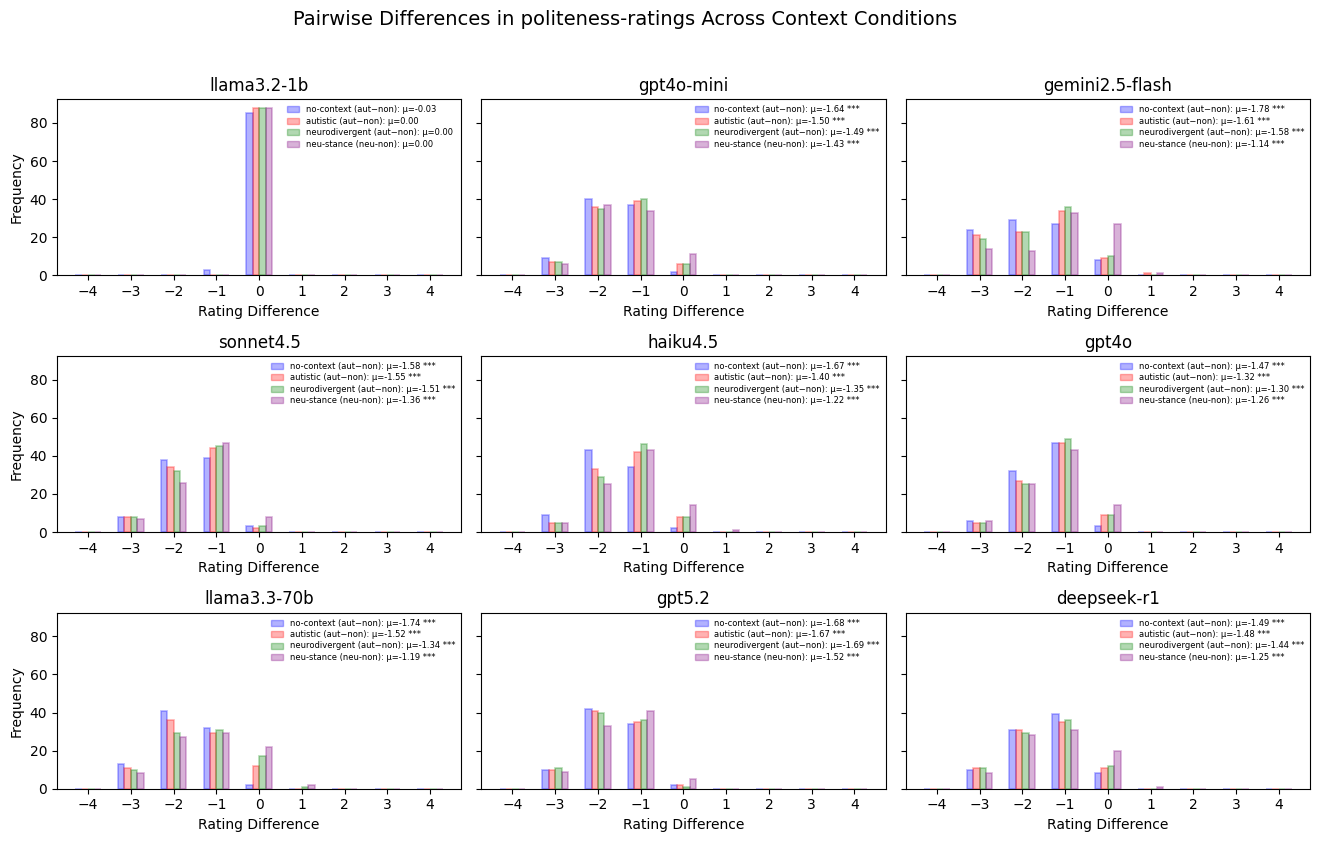

In [559]:

conditions_to_plot = [
    ("no-context", "blue", "no-context (aut−non)"),
    ("autistic", "red", "autistic (aut−non)"),
    ("neurodivergent", "green", "neurodivergent (aut−non)"),
    ("neurodiversity-informed", "purple", "neu-stance (neu-non)")
]
baseline_file_name = "blunt_non_aut.json"
pairwise_visualise(analysis_df, models.keys(), conditions_to_plot, baseline_file_name, task)